# EDA — Digital Public Procurement, Pays de la Loire 2015–2024

Two sources:
- **BOAMP** — 3,181 notices (177–398/year, 2015–2024), full download from the Opendatasoft Explore API  
- **DECP** — 3 039 contracts (2018–2024), from `decp.parquet` (SIRENE-enriched tabular consolidation)

Scope: CPV divisions 48/72/32/35 (digital), departments 44/49/53/72/85 (PdL).

In [1]:
import warnings, json
warnings.filterwarnings('ignore')

from pathlib import Path
import textwrap

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# ── Output paths ──────────────────────────────────────────────────────────
PROJ = Path.cwd()
for _c in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (_c / "data" / "processed").exists():
        PROJ = _c
        break

FIGURES = PROJ / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
RAW_BOAMP = PROJ / "data" / "raw" / "boamp_full"
RAW_DECP = PROJ / "data" / "raw" / "decp" / "decp.parquet"
PROCESSED = PROJ / "data" / "processed"
PDL_DEPTS = ["44", "49", "53", "72", "85"]
DIGITAL_CPV = ("48", "72", "32", "35")
ROUND = [12, 24, 36, 48]
cpv_div_labels = {
    "30": "30 - Office/computing machinery",
    "32": "32 - Radio/telecom equipment",
    "35": "35 - Security equipment",
    "48": "48 - Software packages",
    "72": "72 - IT services",
}

# ── Academic colour palette ───────────────────────────────────────────────
COLORS = {
    "blue":       "#1b6ca8",
    "orange":     "#e05c00",
    "green":      "#2a9d1e",
    "red":        "#9c2020",
    "purple":     "#6a3d9c",
    "gray":       "#555555",
    "light_gray": "#d8d8d8",
}
PALETTE = [COLORS[k] for k in ["blue", "orange", "green", "red", "purple", "gray"]]

SAVE_KW = {"dpi": 300, "bbox_inches": "tight", "facecolor": "white"}

# ── Academic figure style ─────────────────────────────────────────────────
try:
    plt.style.use("seaborn-v0_8-paper")
except OSError:
    try:
        plt.style.use("seaborn-paper")
    except OSError:
        pass

plt.rcParams.update({
    "font.family":          "serif",
    "font.size":            11,
    "axes.titlesize":       13,
    "axes.labelsize":       12,
    "axes.spines.top":      False,
    "axes.spines.right":    False,
    "axes.grid":            True,
    "grid.alpha":           0.25,
    "grid.linestyle":       "--",
    "grid.linewidth":       0.6,
    "legend.frameon":       True,
    "legend.framealpha":    0.85,
    "legend.edgecolor":     "0.8",
    "lines.linewidth":      1.8,
    "figure.dpi":           120,
    "savefig.dpi":          300,
    "savefig.bbox":         "tight",
    "xtick.direction":      "out",
    "ytick.direction":      "out",
    "xtick.minor.visible":  True,
    "ytick.minor.visible":  True,
})

def save_fig(fig, filename):
    """Show figure inline, then save to FIGURES directory."""
    fig.tight_layout()
    from IPython.display import display
    display(fig)
    fig.savefig(FIGURES / filename, **SAVE_KW)
    plt.close(fig)
    print(f"Saved → {FIGURES / filename}")

def finish_axes(ax, grid_axis='y'):
    """Apply consistent final axis styling before saving."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis=grid_axis, alpha=0.25, linestyle='--', linewidth=0.6)
    return ax

def wrap_labels(labels, width=18):
    """Wrap tick labels without changing their values."""
    return ['\n'.join(textwrap.wrap(str(label), width=width)) for label in labels]

print("Academic figure style configured.")


Academic figure style configured.


---
## 0  Data loading — raw vs cleaned

This section reads each source at the **raw** level first, then loads the **processed flat CSV** and shows exactly what the parsing / filtering step changed.

### 0.1  BOAMP — raw JSON (one API page)

In [2]:
# Load one raw page to inspect the API record structure
sample_page = sorted(RAW_BOAMP.glob('*.json'))[0]
with open(sample_page) as f:
    raw_page = json.load(f)

print(f'File            : {sample_page.name}')
print(f'Top-level keys  : {list(raw_page.keys())}')
print(f'Records in page : {len(raw_page["results"])}')

rec0 = raw_page['results'][0]
print(f'\nTop-level fields of one record (excluding donnees):')
for k, v in rec0.items():
    if k != 'donnees':
        print(f'  {k!r:35s} → {str(v)[:80]}')

File            : 2015_p1.json
Top-level keys  : ['total_count', 'results']
Records in page : 100

Top-level fields of one record (excluding donnees):
  'idweb'                             → 15-30334
  'id'                                → 15_30334
  'contractfolderid'                  → None
  'objet'                             → transport collectif à titre principal scolaire par véhicules légers de capacité 
  'filename'                          → BOAMP-J-AO_2015_061003
  'famille'                           → JOUE
  'code_departement'                  → ['53']
  'code_departement_prestation'       → 53
  'famille_libelle'                   → Marchés européens
  'dateparution'                      → 2015-03-02
  'datefindiffusion'                  → 2015-04-13
  'datelimitereponse'                 → 2015-04-13T16:30:00+00:00
  'nomacheteur'                       → Conseil Général de la Mayenne
  'titulaire'                         → None
  'perimetre'                         → DIRECT

In [3]:
# The `donnees` field is a JSON-encoded string with the full notice body
donnees_raw = rec0['donnees']
donnees = json.loads(donnees_raw) if isinstance(donnees_raw, str) else donnees_raw

print(f'donnees type   : {type(donnees_raw).__name__}')
print(f'donnees length : {len(str(donnees_raw))} chars')
print(f'\nTop-level keys inside donnees:')
for k in list(donnees.keys())[:20]:
    v = donnees[k]
    preview = str(v)[:70] + ('…' if len(str(v)) > 70 else '')
    print(f'  {k!r:40s} ({type(v).__name__}) {preview}')

donnees type   : str
donnees length : 12994 chars

Top-level keys inside donnees:
  'IDENTITE'                               (dict) {'DENOMINATION': 'Conseil Général de la Mayenne', 'CORRESPONDANT': 'M.…
  'TYPE_POUVOIR_ADJUDICATEUR'              (dict) {'AUTOTRITE_REGIONAL': ''}
  'ACTIVITE_PRINCIPALE'                    (dict) {'POUVOIR_ADJUDICATEUR': {'ACT_SERV_ADM_PUB': ''}}
  'OBJET'                                  (dict) {'TITRE_MARCHE': 'Transport collectif à titre principal scolaire par v…
  'PROCEDURE'                              (dict) {'TYPE_PROCEDURE': {'OUVERT': ''}, 'ENCHERE_ELECTRONIQUE_NON': '', 'FO…
  'PUBLICATION_ANTERIEURE'                 (dict) {'NON': ''}
  'CONDITION_DELAI'                        (dict) {'RECEPT_OFFRES': '2015-04-13T17:30:00+01:00', 'VALIDITE_OFFRE': {'DUR…
  'CONDITION_RELATIVE_MARCHE'              (dict) {'CAUTIONNEMENT': 'Sans objet.', 'FINANCEMENT': "Modalités de financem…
  'CONDITION_PARTICIPATION'                (dict) {'SITUATION_JURIDI

In [4]:
# Load ALL raw pages into a DataFrame (top-level fields only, no donnees parsing)
all_raw_records = []
for path in sorted(RAW_BOAMP.glob('*.json')):
    with open(path) as f:
        page = json.load(f)
    all_raw_records.extend(page['results'])

raw_boamp = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'donnees'}
    for r in all_raw_records
])

print(f'Raw BOAMP records : {len(raw_boamp)}')
print(f'Shape             : {raw_boamp.shape}')
print(f'Columns           : {list(raw_boamp.columns)}')
raw_boamp.head(3)

Raw BOAMP records : 34362
Shape             : (34362, 40)
Columns           : ['idweb', 'id', 'contractfolderid', 'objet', 'filename', 'famille', 'code_departement', 'code_departement_prestation', 'famille_libelle', 'dateparution', 'datefindiffusion', 'datelimitereponse', 'nomacheteur', 'titulaire', 'perimetre', 'type_procedure', 'soustype_procedure', 'procedure_libelle', 'procedure_categorise', 'nature', 'sousnature', 'nature_libelle', 'sousnature_libelle', 'nature_categorise', 'nature_categorise_libelle', 'criteres', 'marche_public_simplifie', 'marche_public_simplifie_label', 'etat', 'descripteur_code', 'dc', 'descripteur_libelle', 'type_marche', 'type_marche_facette', 'type_avis', 'annonce_lie', 'annonces_anterieures', 'source_schema', 'gestion', 'url_avis']


,idweb,id,contractfolderid,objet,filename,famille,code_departement,code_departement_prestation,famille_libelle,dateparution,...,dc,descripteur_libelle,type_marche,type_marche_facette,type_avis,annonce_lie,annonces_anterieures,source_schema,gestion,url_avis
0,15-30334,15_30334,None,transport collectif à titre principal scolaire...,BOAMP-J-AO_2015_061003,JOUE,[53],53,Marchés européens,2015-03-02,...,"[274, 347]","[Prestations de services, Transport]",[SERVICES],[Services],"[5, 1, ]",None,None,Boamp_v230.xsd,"{""REFERENCE"": {""IDWEB"": ""15-30334"", ""TYPE_AVIS...",https://www.boamp.fr/pages/avis/?q=idweb:15-30334
1,15-30947,15_30947,None,Acquisition de systèmes d'identification embar...,BOAMP-J-AO_2015_061003,JOUE,[49],49,Marchés européens,2015-03-02,...,"[162, 185, 186, 196]","[Informatique (matériel), Location, Logiciel, ...",[SERVICES],[Services],"[5, 1, ]",None,None,Boamp_v230.xsd,"{""REFERENCE"": {""IDWEB"": ""15-30947"", ""TYPE_AVIS...",https://www.boamp.fr/pages/avis/?q=idweb:15-30947
2,15-31011,15_31011,None,prestations de surveillance et de gardiennage ...,BOAMP-N-AO_2015_061005,FNS,[49],49,Marchés entre 90 k€ et seuils européens,2015-03-02,...,"[138, 331]","[Gardiennage, Surveillance]",[SERVICES],[Services],"[5, 1, ]",None,None,Boamp_v230.xsd,"{""REFERENCE"": {""IDWEB"": ""15-31011"", ""TYPE_AVIS...",https://www.boamp.fr/pages/avis/?q=idweb:15-31011


### 0.2  BOAMP — cleaned flat CSV

The flat CSV was produced by parsing every notice's nested `donnees` blob using `extract_boamp_features()` in `scripts/utils.py`.

In [5]:
cleaned_boamp = pd.read_csv(PROCESSED / 'boamp_full_flat.csv', low_memory=False)

print(f'Cleaned BOAMP shape : {cleaned_boamp.shape}')
print(f'Columns             : {list(cleaned_boamp.columns)}')
cleaned_boamp.head(3)

Cleaned BOAMP shape : (3181, 30)
Columns             : ['idweb', 'dateparution', 'datefindiffusion', 'datelimitereponse', 'nomacheteur', 'code_departement', 'famille', 'nature', 'nature_libelle', 'type_procedure', 'type_marche', 'type_avis', 'descripteur_libelle', 'objet', 'titulaire', 'annonce_lie', 'contractfolderid', 'etat', 'url_avis', 'donnees_format', 'cpv_principal', 'cpv_all', 'buyer_siret', 'buyer_cp', 'buyer_ville', 'amount_eur', 'duration_months', 'duration_source_field', 'date_attribution', 'date_publication_anterieure']


,idweb,dateparution,datefindiffusion,datelimitereponse,nomacheteur,code_departement,famille,nature,nature_libelle,type_procedure,...,cpv_principal,cpv_all,buyer_siret,buyer_cp,buyer_ville,amount_eur,duration_months,duration_source_field,date_attribution,date_publication_anterieure
0,15-30947,2015-03-02,2015-03-27,2015-03-27T11:30:00+00:00,SMICTOM de la Vallée de l'Authion,49,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,48000000.0,48000000,NaN,49250,Beaufort en vallee,150000.0,12.0,DUREE_MOIS,NaN,NaN
1,15-31464,2015-03-02,2015-04-24,2015-04-24T15:00:00+00:00,Sdis de la Mayenne,53,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,NaN,None|35311400|31121000|34928410|44423200|43830...,NaN,53005,Laval cedex,NaN,36.0,DUREE_MOIS,NaN,NaN
2,15-31513,2015-03-02,2015-04-17,2015-04-17T11:00:00+00:00,Ville de Rezé,44,JOUE,APPEL_OFFRE,Avis de marché,OUVERT,...,38720000.0,38720000|31224500|48620000,NaN,44403,Rezé Cedex,NaN,48.0,DUREE_MOIS,NaN,NaN


In [6]:
# Fields added by parsing donnees vs raw top-level
raw_cols     = set(raw_boamp.columns) | {'donnees'}
cleaned_cols = set(cleaned_boamp.columns)

added   = sorted(cleaned_cols - raw_cols)
removed = sorted(raw_cols - cleaned_cols - {'donnees'})

print('Fields ADDED by donnees parsing:')
for c in added:
    pct = cleaned_boamp[c].notna().mean() * 100
    print(f'  + {c:<35s}  {pct:5.1f}% filled')

if removed:
    print(f'\nFields REMOVED / renamed:')
    for c in removed:
        print(f'  - {c}')

Fields ADDED by donnees parsing:
  + amount_eur                            43.0% filled
  + buyer_cp                              96.5% filled
  + buyer_siret                            9.1% filled
  + buyer_ville                           99.6% filled
  + cpv_all                              100.0% filled
  + cpv_principal                         98.1% filled
  + date_attribution                      31.8% filled
  + date_publication_anterieure           18.6% filled
  + donnees_format                       100.0% filled
  + duration_months                       47.7% filled
  + duration_source_field                 47.7% filled

Fields REMOVED / renamed:
  - annonces_anterieures
  - code_departement_prestation
  - criteres
  - dc
  - descripteur_code
  - famille_libelle
  - filename
  - gestion
  - id
  - marche_public_simplifie
  - marche_public_simplifie_label
  - nature_categorise
  - nature_categorise_libelle
  - perimetre
  - procedure_categorise
  - procedure_libelle
  - source

In [7]:
# Side-by-side: one raw record vs its cleaned row
sample_id = cleaned_boamp.iloc[0]['idweb']
raw_row = raw_boamp[raw_boamp['idweb'] == sample_id].iloc[0]
cln_row = cleaned_boamp[cleaned_boamp['idweb'] == sample_id].iloc[0]

print(f'idweb: {sample_id}')
print(f'\n{"Field":<35}  {"RAW value":<50}  CLEANED value')
print('-' * 120)
all_fields = sorted((set(raw_row.index) | set(cln_row.index)) - {'donnees'})
for f in all_fields:
    rv = str(raw_row.get(f, '—'))[:50]
    cv = str(cln_row.get(f, '—'))[:50]
    marker = '*' if f not in raw_row.index else (' ' if rv == cv else '~')
    if marker != ' ':
        print(f'{marker} {f:<35}  {rv:<50}  {cv}')

idweb: 15-30947

Field                                RAW value                                           CLEANED value
------------------------------------------------------------------------------------------------------------------------
* amount_eur                           —                                                   150000.0
~ annonce_lie                          None                                                nan
~ annonces_anterieures                 None                                                —
* buyer_cp                             —                                                   49250
* buyer_siret                          —                                                   nan
* buyer_ville                          —                                                   Beaufort en vallee
~ code_departement                     ['49']                                              49
~ code_departement_prestation          49                                  

### 0.3  DECP — raw parquet

In [8]:
raw_decp = pd.read_parquet(RAW_DECP)

print(f'Raw DECP parquet shape : {raw_decp.shape}')
print(f'Columns ({len(raw_decp.columns)})           : {list(raw_decp.columns)}')
raw_decp.dtypes

Raw DECP parquet shape : (3075779, 58)
Columns (58)           : ['uid', 'id', 'nature', 'acheteur_id', 'acheteur_nom', 'titulaire_id', 'titulaire_typeIdentifiant', 'titulaire_nom', 'objet', 'montant', 'type', 'codeCPV', 'procedure', 'techniques', 'dureeMois', 'dureeRestanteMois', 'offresRecues', 'dateNotification', 'datePublicationDonnees', 'formePrix', 'typesPrix', 'attributionAvance', 'tauxAvance', 'marcheInnovant', 'modalitesExecution', 'considerationsSociales', 'considerationsEnvironnementales', 'ccag', 'sousTraitanceDeclaree', 'typeGroupementOperateurs', 'origineUE', 'origineFrance', 'lieuExecution_code', 'lieuExecution_typeCode', 'idAccordCadre', 'titulaire_distance', 'acheteur_categorie', 'acheteur_commune_code', 'acheteur_commune_nom', 'acheteur_departement_code', 'acheteur_departement_nom', 'acheteur_region_code', 'acheteur_region_nom', 'acheteur_latitude', 'acheteur_longitude', 'titulaire_categorie', 'titulaire_commune_code', 'titulaire_commune_nom', 'titulaire_departement_co

uid                                 object
id                                  object
nature                              object
acheteur_id                         object
acheteur_nom                        object
titulaire_id                        object
titulaire_typeIdentifiant           object
titulaire_nom                       object
objet                               object
montant                            float64
type                                object
codeCPV                             object
procedure                           object
techniques                          object
dureeMois                          float64
dureeRestanteMois                  float64
offresRecues                       float64
dateNotification                    object
datePublicationDonnees              object
formePrix                           object
typesPrix                           object
attributionAvance                   object
tauxAvance                         float32
marcheInnov

In [9]:
raw_decp.head(3)

,uid,id,nature,acheteur_id,acheteur_nom,titulaire_id,titulaire_typeIdentifiant,titulaire_nom,objet,montant,...,titulaire_departement_code,titulaire_departement_nom,titulaire_region_code,titulaire_region_nom,titulaire_latitude,titulaire_longitude,modification_id,donneesActuelles,sourceDataset,sourceFile
0,120012018001111300214414,1300214414,Marché,12001201800111,DIRECTION GENERALE DE L'ADMINISTRATION PENITEN...,49858885400014,SIRET,SONOMA,Le marché spécifique a pour objet l’acquisitio...,277017.02,...,31,Haute-Garonne,76,Occitanie,43.505282,1.362516,0.0,True,aife_dume,https://www.data.gouv.fr/datasets/5df410e86f44...
1,130001704005891100071040,1100071040,Marché,13000170400589,DIRECTION INTERDEPARTEMENTALE DES ROUTES OUEST,44334274600031,SIRET,SWARCO FRANCE,"Fourniture, pose, raccordement et mise en serv...",718009.00,...,06,Alpes-Maritimes,93,Provence-Alpes-Côte d'Azur,43.788036,7.206692,0.0,True,aife_dume,https://www.data.gouv.fr/datasets/5df410e86f44...
2,130001738000171513699809,1513699809,Marché,13000173800017,DIRECTION INTERDEPARTEMENTALE DES ROUTES CENTR...,32933888302340,SIRET,COLAS FRANCE (ETABLISSEMENT LOIRE HAUTE-LOIRE),Travaux complémentaires au renforcement du mur...,910716.25,...,42,Loire,84,Auvergne-Rhône-Alpes,45.431190,4.430824,0.0,True,aife_dume,https://www.data.gouv.fr/datasets/5df410e86f44...


In [10]:
raw_missing = (raw_decp.isna().mean() * 100).sort_values(ascending=False)
print('Raw DECP — missing % per field (top 20):')
print(raw_missing.head(20).round(1).to_string())

Raw DECP — missing % per field (top 20):
idAccordCadre                      90.3
origineFrance                      89.8
origineUE                          89.8
tauxAvance                         81.5
marcheInnovant                     72.5
attributionAvance                  71.9
sousTraitanceDeclaree              62.1
offresRecues                       60.7
typesPrix                          51.8
modalitesExecution                 46.6
techniques                         46.6
considerationsSociales             46.3
considerationsEnvironnementales    46.3
ccag                               45.3
typeGroupementOperateurs           44.9
titulaire_distance                 20.9
titulaire_latitude                 14.9
titulaire_longitude                14.9
acheteur_categorie                 14.7
acheteur_latitude                   7.4


### 0.4  DECP — cleaned flat CSV (after filtering)

In [11]:
cleaned_decp = pd.read_csv(PROCESSED / 'decp_sample_flat.csv', low_memory=False)

print(f'Cleaned DECP shape : {cleaned_decp.shape}')
print(f'Columns            : {list(cleaned_decp.columns)}')
cleaned_decp.head(3)

Cleaned DECP shape : (3039, 22)
Columns            : ['uid', 'id', 'nature', 'objet', 'codeCPV', 'procedure', 'dureeMois', 'dateNotification', 'datePublicationDonnees', 'montant', 'offresRecues', 'donneesActuelles', 'sourceDataset', 'acheteur_id', 'acheteur_nom', 'acheteur_departement_code', 'acheteur_categorie', 'titulaire_id', 'titulaire_typeIdentifiant', 'titulaire_nom', 'lieuExecution_code', 'lieuExecution_typeCode']


,uid,id,nature,objet,codeCPV,procedure,dureeMois,dateNotification,datePublicationDonnees,montant,...,sourceDataset,acheteur_id,acheteur_nom,acheteur_departement_code,acheteur_categorie,titulaire_id,titulaire_typeIdentifiant,titulaire_nom,lieuExecution_code,lieuExecution_typeCode
0,214401622000112024K-P0rgdsDS00,2024K-P0rgdsDS00,Marché,TIERCE MAINTENANCE APPLICATIVE DU LOGICIEL CAP...,72267000,Marché passé sans publicité ni mise en concurr...,48.0,2024-12-31,2025-03-13,140000.0,...,aife_dume,21440162200011,COMMUNE DE SAINT-HERBLAIN (MAIRIE),44,Commune,80337757100044,SIRET,CAP COLLECTIF,44,Code département
1,2444005520002625-1065514,25-1065514,Marché,Marché négocié sans publicité et sans mise en ...,48000000,Procédure adaptée,48.0,2024-12-31,2025-01-16,174400.0,...,e-marchespublics.com_dematis,24440055200026,COMMUNAUTE DE COMMUNES DU PAYS D'ANCENIS,44,Groupement de communes,42050508300030,SIRET,TRADIM,44150,Code postal
2,200033298000152024M02124000000,2024M02124000000,Marché,Prestations d’utilisation d’une plateforme SME...,72314000,Procédure adaptée,48.0,2024-12-27,2025-01-29,80000.0,...,scrap_marches-securises.fr,20003329800015,COMMUNAUTE DE COMMUNES DES COEVRONS,53,Groupement de communes,53380571900036,SIRET,EVELER,53600,Code postal


In [12]:
# Reproduce the filtering funnel step by step
mask_curr = raw_decp['donneesActuelles'].astype(str).str.lower() == 'true'
mask_cpv  = raw_decp['codeCPV'].astype(str).str.startswith(DIGITAL_CPV)
mask_dept = raw_decp['acheteur_departement_code'].astype(str).isin(PDL_DEPTS)
mask_date = pd.to_datetime(raw_decp['dateNotification'], errors='coerce').dt.year.between(2015, 2024)

print('DECP filtering funnel (rows retained at each step):')
print(f'  Raw parquet                          : {len(raw_decp):>10,}')
print(f'  + current version (donneesActuelles) : {mask_curr.sum():>10,}')
print(f'  + digital CPV (48/72/32/35)          : {(mask_curr & mask_cpv).sum():>10,}')
print(f'  + PdL buyer department               : {(mask_curr & mask_cpv & mask_dept).sum():>10,}')
print(f'  + 2015–2024 notification date        : {(mask_curr & mask_cpv & mask_dept & mask_date).sum():>10,}')
print(f'  Cleaned CSV (loaded above)           : {len(cleaned_decp):>10,}')

DECP filtering funnel (rows retained at each step):
  Raw parquet                          :  3,075,779
  + current version (donneesActuelles) :  1,966,250
  + digital CPV (48/72/32/35)          :     79,641
  + PdL buyer department               :      3,967
  + 2015–2024 notification date        :      3,039
  Cleaned CSV (loaded above)           :      3,039


In [13]:
# Column set comparison: raw parquet vs cleaned CSV
raw_cols_d     = set(raw_decp.columns)
cleaned_cols_d = set(cleaned_decp.columns)

dropped = sorted(raw_cols_d - cleaned_cols_d)
added   = sorted(cleaned_cols_d - raw_cols_d)

print(f'Columns in raw parquet : {len(raw_cols_d)}')
print(f'Columns in cleaned CSV : {len(cleaned_cols_d)}')
if dropped:
    print(f'\nDropped ({len(dropped)}):')
    for c in dropped: print(f'  - {c}')
if added:
    print(f'\nAdded by SIRENE enrichment ({len(added)}):')
    for c in added: print(f'  + {c}')

# Completion change for shared fields (filtering improves completeness for PdL-specific fields)
shared = sorted(raw_cols_d & cleaned_cols_d)
print('\nCompletion change for shared fields (raw % → cleaned %) — changed fields only:')
for c in shared:
    r_pct = raw_decp[c].notna().mean() * 100
    c_pct = cleaned_decp[c].notna().mean() * 100
    if abs(r_pct - c_pct) > 0.5:
        print(f'  {c:<40s}  {r_pct:5.1f}% → {c_pct:5.1f}%')

Columns in raw parquet : 58
Columns in cleaned CSV : 22

Dropped (36):
  - acheteur_commune_code
  - acheteur_commune_nom
  - acheteur_departement_nom
  - acheteur_latitude
  - acheteur_longitude
  - acheteur_region_code
  - acheteur_region_nom
  - attributionAvance
  - ccag
  - considerationsEnvironnementales
  - considerationsSociales
  - dureeRestanteMois
  - formePrix
  - idAccordCadre
  - marcheInnovant
  - modalitesExecution
  - modification_id
  - origineFrance
  - origineUE
  - sourceFile
  - sousTraitanceDeclaree
  - tauxAvance
  - techniques
  - titulaire_categorie
  - titulaire_commune_code
  - titulaire_commune_nom
  - titulaire_departement_code
  - titulaire_departement_nom
  - titulaire_distance
  - titulaire_latitude
  - titulaire_longitude
  - titulaire_region_code
  - titulaire_region_nom
  - type
  - typeGroupementOperateurs
  - typesPrix

Completion change for shared fields (raw % → cleaned %) — changed fields only:


  acheteur_categorie                         85.3% →  84.7%
  acheteur_departement_code                  99.3% → 100.0%


  acheteur_nom                               99.4% → 100.0%
  dateNotification                           99.0% → 100.0%


  datePublicationDonnees                     95.2% →  98.0%
  donneesActuelles                           99.0% → 100.0%


  montant                                    98.4% →  95.6%


  offresRecues                               39.3% →  26.4%
  procedure                                  95.2% →  85.4%


  titulaire_id                               96.9% →  95.5%
  titulaire_nom                              95.6% →  93.6%
  titulaire_typeIdentifiant                  97.0% →  95.5%


---
## 1  BOAMP sample — EDA

In [14]:
boamp = pd.read_csv(
    PROCESSED / 'boamp_full_flat.csv',
    dtype={'code_departement': str, 'cpv_principal': str,
           'buyer_siret': str, 'buyer_cp': str},
    low_memory=False,
)

boamp['dateparution']  = pd.to_datetime(boamp['dateparution'],  errors='coerce')
boamp['date_attribution'] = pd.to_datetime(boamp['date_attribution'], errors='coerce')
boamp['date_publication_anterieure'] = pd.to_datetime(
    boamp['date_publication_anterieure'], errors='coerce')
boamp['year'] = boamp['dateparution'].dt.year

print(f'Shape: {boamp.shape}')
boamp.dtypes

Shape: (3181, 31)


idweb                                  object
dateparution                   datetime64[ns]
datefindiffusion                       object
datelimitereponse                      object
nomacheteur                            object
code_departement                       object
famille                                object
nature                                 object
nature_libelle                         object
type_procedure                         object
type_marche                            object
type_avis                              object
descripteur_libelle                    object
objet                                  object
titulaire                              object
annonce_lie                            object
contractfolderid                       object
etat                                   object
url_avis                               object
donnees_format                         object
cpv_principal                          object
cpv_all                           

### 1.1  Completeness overview

In [15]:
def missing_pct(df):
    m = 100 * df.isna().mean()
    return (m
            .where(m > 0)
            .dropna()
            .sort_values(ascending=False)
            .rename('missing %')
            .to_frame()
            .assign(**{'non-null': lambda x: (df.shape[0] * (1 - x['missing %'] / 100)).astype(int)})
           )

missing_pct(boamp)

,missing %,non-null
contractfolderid,90.946243,287
buyer_siret,90.946243,287
date_publication_anterieure,81.358064,592
datelimitereponse,73.970450,827
titulaire,72.367180,879
date_attribution,71.015404,921
annonce_lie,65.136749,1109
amount_eur,56.963219,1368
duration_source_field,52.279157,1518
duration_months,52.279157,1518


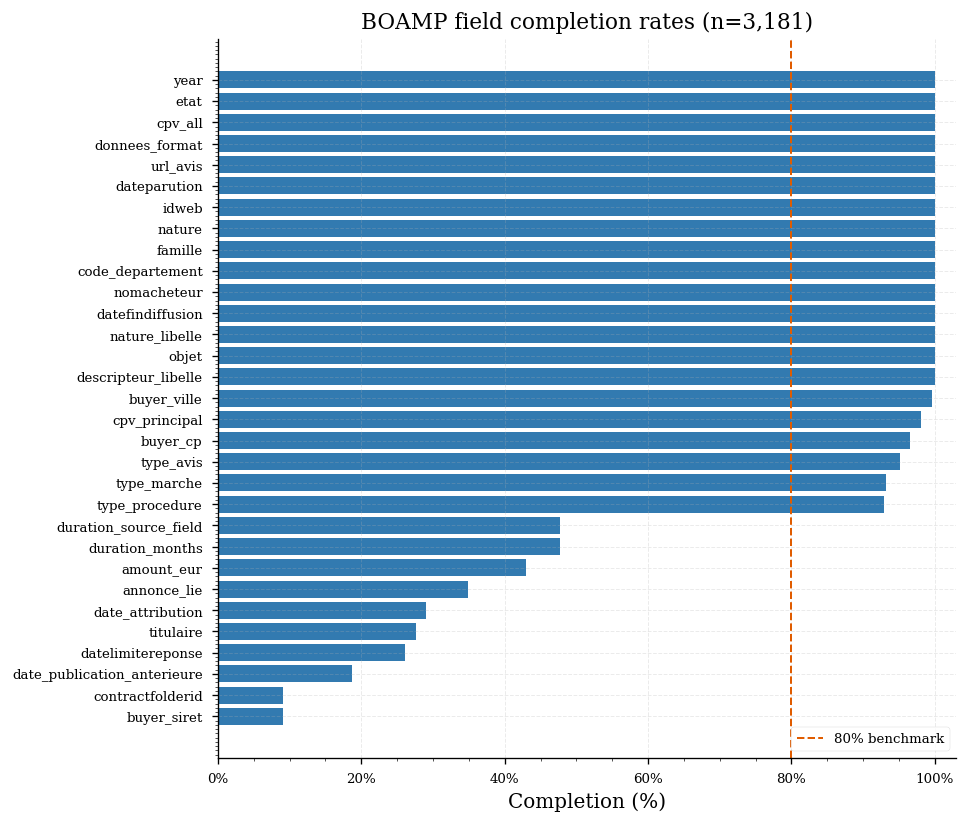

Saved → /home/senghakrou/stage-1/reports/figures/boamp_completion.png


In [16]:
fill = (100 * boamp.notna().mean()).sort_values()
fig, ax = plt.subplots(figsize=(8.2, 7.0))
ax.barh(fill.index, fill.values, color=COLORS['blue'], alpha=0.9)
ax.axvline(80, color=COLORS['orange'], linestyle='--', linewidth=1.2,
           label='80% benchmark')
ax.set(title=f'BOAMP field completion rates (n={len(boamp):,})',
       xlabel='Completion (%)', ylabel='', xlim=(0, 103))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend(loc='lower right')
finish_axes(ax, grid_axis='x')
save_fig(fig, 'boamp_completion.png')
plt.show()

### 1.2  Temporal distribution

In [17]:
print('Notices per year:')
print(boamp['year'].value_counts().sort_index().to_string())

Notices per year:
year
2015    177
2016    278
2017    315
2018    328
2019    313
2020    343
2021    342
2022    398
2023    389
2024    298


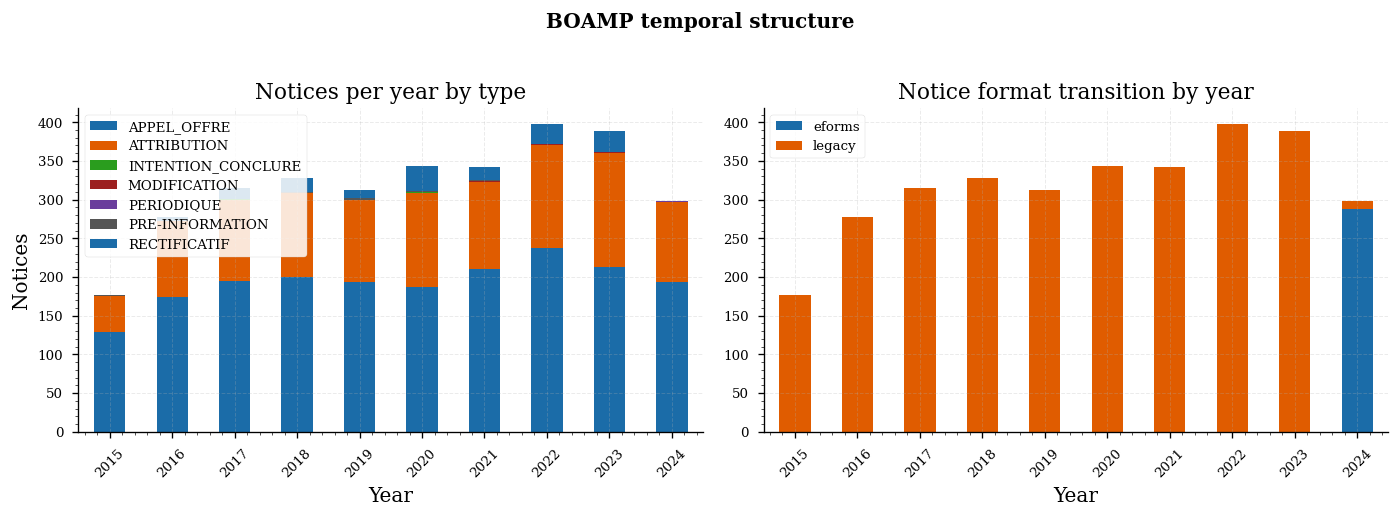

Saved → /home/senghakrou/stage-1/reports/figures/boamp_temporal.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2))

pivot = boamp.groupby(['year', 'nature']).size().unstack(fill_value=0)
pivot.plot.bar(stacked=True, ax=axes[0], legend=True, color=PALETTE[:pivot.shape[1]])
axes[0].set(title='Notices per year by type', xlabel='Year', ylabel='Notices')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='', fontsize=8, loc='upper left')
finish_axes(axes[0])

fmt = boamp.groupby(['year', 'donnees_format']).size().unstack(fill_value=0)
fmt.plot.bar(stacked=True, ax=axes[1], color=PALETTE[:fmt.shape[1]])
axes[1].set(title='Notice format transition by year', xlabel='Year', ylabel='')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='', fontsize=8, loc='upper left')
finish_axes(axes[1])

fig.suptitle('BOAMP temporal structure', y=1.02, fontsize=12, fontweight='bold')
save_fig(fig, 'boamp_temporal.png')
plt.show()

### 1.3  Notice types and states

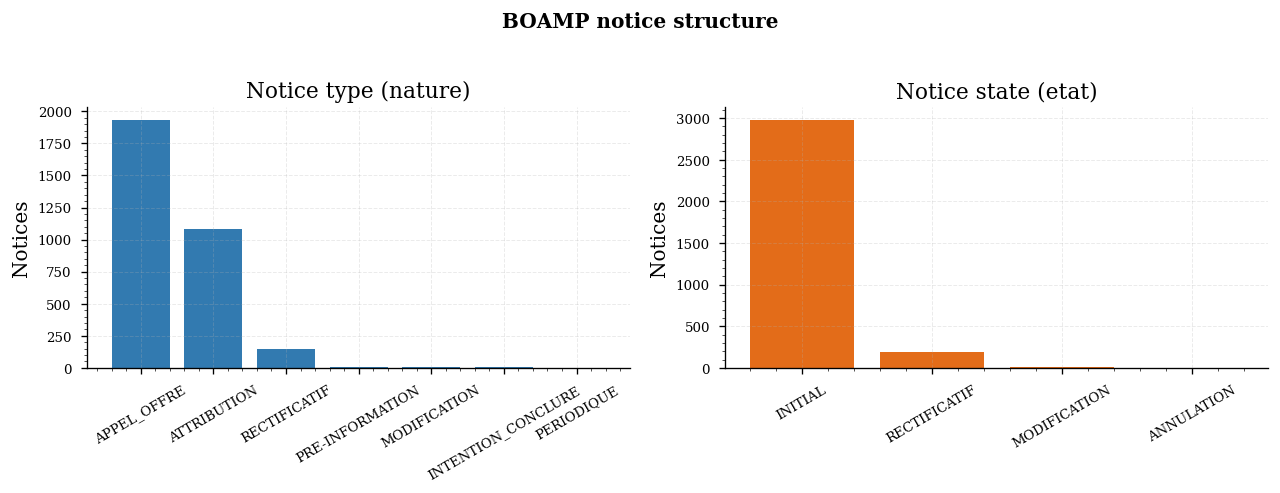

Saved → /home/senghakrou/stage-1/reports/figures/boamp_notice_types.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.0))

nature = boamp['nature'].value_counts()
axes[0].bar(nature.index, nature.values, color=COLORS['blue'], alpha=0.9)
axes[0].set(title='Notice type (nature)', ylabel='Notices')
axes[0].tick_params(axis='x', rotation=30)
finish_axes(axes[0])

etat = boamp['etat'].value_counts()
axes[1].bar(etat.index, etat.values, color=COLORS['orange'], alpha=0.9)
axes[1].set(title='Notice state (etat)', ylabel='Notices')
axes[1].tick_params(axis='x', rotation=30)
finish_axes(axes[1])

fig.suptitle('BOAMP notice structure', y=1.02, fontsize=12, fontweight='bold')
save_fig(fig, 'boamp_notice_types.png')
plt.show()

### 1.4  Department and procedure

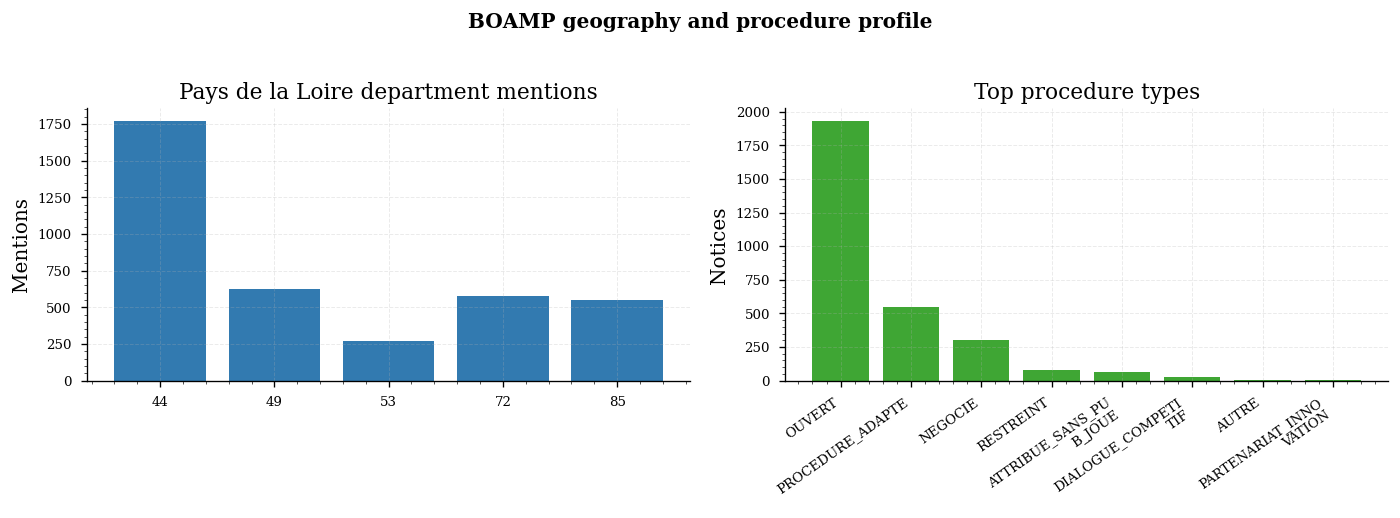

Saved → /home/senghakrou/stage-1/reports/figures/boamp_dept_procedure.png


In [20]:
dept_series = (
    boamp['code_departement']
    .astype('string')
    .str.split('|')
    .explode()
    .str.strip()
    .dropna()
)
dept_pdl = dept_series[dept_series.isin(PDL_DEPTS)]

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2))

dept_counts = dept_pdl.value_counts().reindex(PDL_DEPTS).fillna(0)
axes[0].bar(dept_counts.index, dept_counts.values, color=COLORS['blue'], alpha=0.9)
axes[0].set(title='Pays de la Loire department mentions', ylabel='Mentions')
finish_axes(axes[0])

procedures = boamp['type_procedure'].value_counts().head(8)
axes[1].bar(range(len(procedures)), procedures.values, color=COLORS['green'], alpha=0.9)
axes[1].set_xticks(range(len(procedures)))
axes[1].set_xticklabels(wrap_labels(procedures.index, width=16), rotation=35, ha='right')
axes[1].set(title='Top procedure types', ylabel='Notices')
finish_axes(axes[1])

fig.suptitle('BOAMP geography and procedure profile', y=1.02, fontsize=12, fontweight='bold')
save_fig(fig, 'boamp_dept_procedure.png')
plt.show()

### 1.5  CPV codes

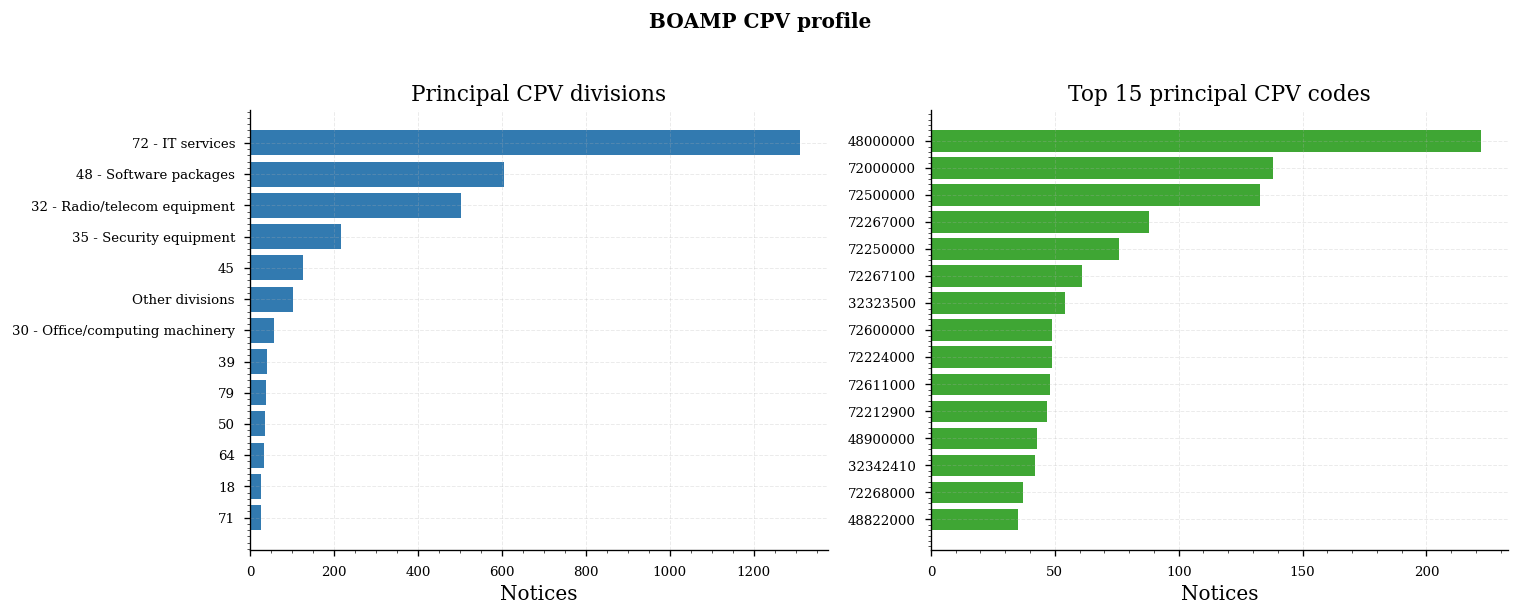

Saved → /home/senghakrou/stage-1/reports/figures/boamp_cpv.png
Generic CPV codes (XX000000): 397 / 3119 (12.7%)


In [21]:
boamp['cpv_div'] = boamp['cpv_principal'].astype('string').str[:2]

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0))

div_counts = boamp['cpv_div'].dropna().value_counts()
div_counts.index = [cpv_div_labels.get(str(x), str(x)) for x in div_counts.index]
top_divisions = div_counts.head(12).copy()
if len(div_counts) > len(top_divisions):
    top_divisions.loc['Other divisions'] = div_counts.iloc[len(top_divisions):].sum()
top_divisions = top_divisions.sort_values()
axes[0].barh(top_divisions.index, top_divisions.values, color=COLORS['blue'], alpha=0.9)
axes[0].set(title='Principal CPV divisions', xlabel='Notices', ylabel='')
finish_axes(axes[0], grid_axis='x')

top_cpv = boamp['cpv_principal'].dropna().value_counts().head(15).sort_values()
axes[1].barh(top_cpv.index.astype(str), top_cpv.values, color=COLORS['green'], alpha=0.9)
axes[1].set(title='Top 15 principal CPV codes', xlabel='Notices', ylabel='')
finish_axes(axes[1], grid_axis='x')

fig.suptitle('BOAMP CPV profile', y=1.02, fontsize=12, fontweight='bold')
save_fig(fig, 'boamp_cpv.png')
plt.show()

generic = boamp['cpv_principal'].dropna().astype(str).str.endswith('000000')
print(f'Generic CPV codes (XX000000): {generic.sum()} / {boamp["cpv_principal"].notna().sum()} '
      f'({generic.mean():.1%})')

### 1.6  Amount distribution

In [22]:
amt = boamp['amount_eur'].dropna()
print(f'Filled: {len(amt)}/{len(boamp)} ({len(amt)/len(boamp):.1%})')
print(amt.describe().to_string())

flags = {
    'amount <= 0'    : int((amt <= 0).sum()),
    'amount < 1 000' : int((amt < 1_000).sum()),
    'amount >= 10 M' : int((amt >= 10_000_000).sum()),
}
for k, v in flags.items():
    print(f'  {k}: {v} ({v/len(amt):.1%})')

Filled: 1369/3181 (43.0%)
count    1.369000e+03
mean     1.461785e+10
std      3.820798e+11
min      0.000000e+00
25%      2.000000e+05
50%      4.000000e+05
75%      9.999990e+05
max      1.000000e+13
  amount <= 0: 1 (0.1%)
  amount < 1 000: 10 (0.7%)
  amount >= 10 M: 53 (3.9%)


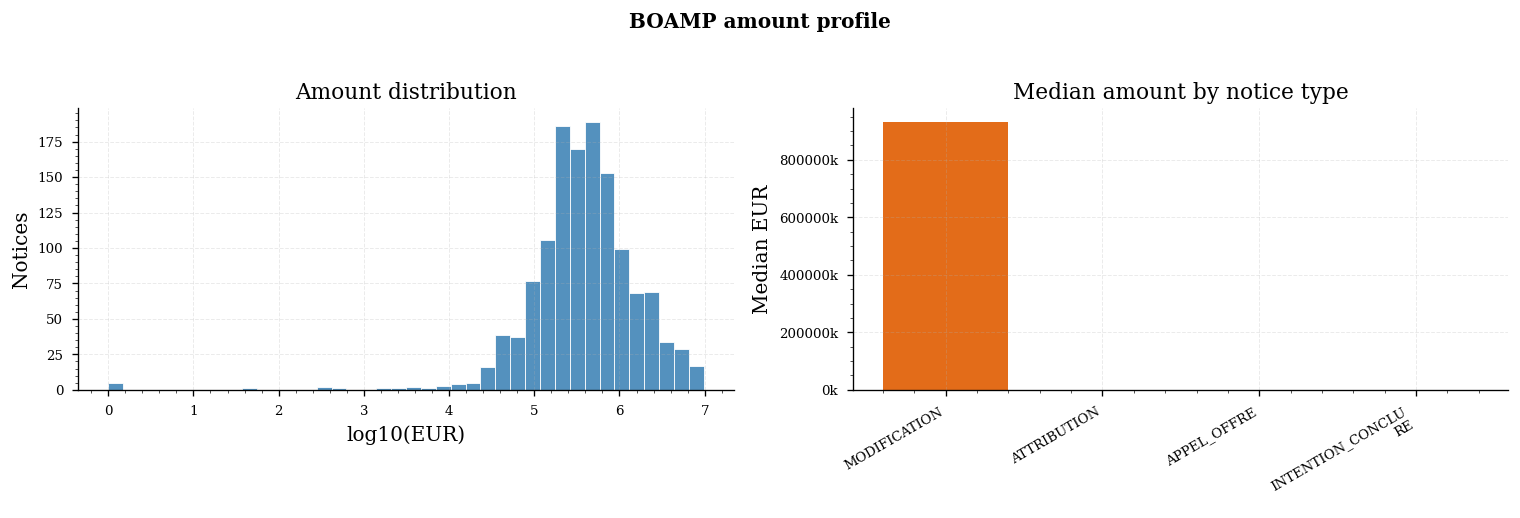

Saved → /home/senghakrou/stage-1/reports/figures/boamp_amount.png


In [23]:
amt_clean = amt[(amt > 0) & (amt < 10_000_000)]

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.2))

sns.histplot(np.log10(amt_clean), bins=40, color=COLORS['blue'],
             edgecolor='white', linewidth=0.5, ax=axes[0])
axes[0].set(title='Amount distribution', xlabel='log10(EUR)', ylabel='Notices')
finish_axes(axes[0])

amt_by_nature = (
    boamp[boamp['amount_eur'].notna()]
    .groupby('nature')['amount_eur']
    .median()
    .sort_values(ascending=False)
)
axes[1].bar(range(len(amt_by_nature)), amt_by_nature.values,
            color=COLORS['orange'], alpha=0.9)
axes[1].set_xticks(range(len(amt_by_nature)))
axes[1].set_xticklabels(wrap_labels(amt_by_nature.index, width=16), rotation=30, ha='right')
axes[1].set(title='Median amount by notice type', ylabel='Median EUR')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
finish_axes(axes[1])

fig.suptitle('BOAMP amount profile', y=1.02, fontsize=12, fontweight='bold')
save_fig(fig, 'boamp_amount.png')
plt.show()

### 1.7  Declared contract duration

In [24]:
dur = boamp['duration_months'].dropna()

print(f'Filled: {len(dur)}/{len(boamp)} ({len(dur)/len(boamp):.1%})')
print(dur.describe().to_string())
print()

flags = {
    'exactly 12/24/36/48 months' : int(dur.isin(ROUND).sum()),
    'any whole-year multiple'    : int((dur % 12 == 0).sum()),
    'duration > 120 months'      : int((dur > 120).sum()),
    'duration <= 0'              : int((dur <= 0).sum()),
}
for k, v in flags.items():
    print(f'  {k}: {v} ({v/len(dur):.1%})')

print('\nDuration by notice type (mean):')
print(boamp.groupby('nature')['duration_months'].agg(['mean', 'count']).to_string())

Filled: 1518/3181 (47.7%)
count    1518.000000
mean       32.798754
std        31.743018
min         0.000000
25%        12.000000
50%        24.000000
75%        48.000000
max       360.000000

  exactly 12/24/36/48 months: 1048 (69.0%)
  any whole-year multiple: 1175 (77.4%)
  duration > 120 months: 11 (0.7%)
  duration <= 0: 1 (0.1%)

Duration by notice type (mean):
                          mean  count
nature                               
APPEL_OFFRE          31.407749   1485
ATTRIBUTION          75.692308     26
INTENTION_CONCLURE         NaN      0
MODIFICATION        226.400000      5
PERIODIQUE                 NaN      0
PRE-INFORMATION      24.000000      2
RECTIFICATIF               NaN      0


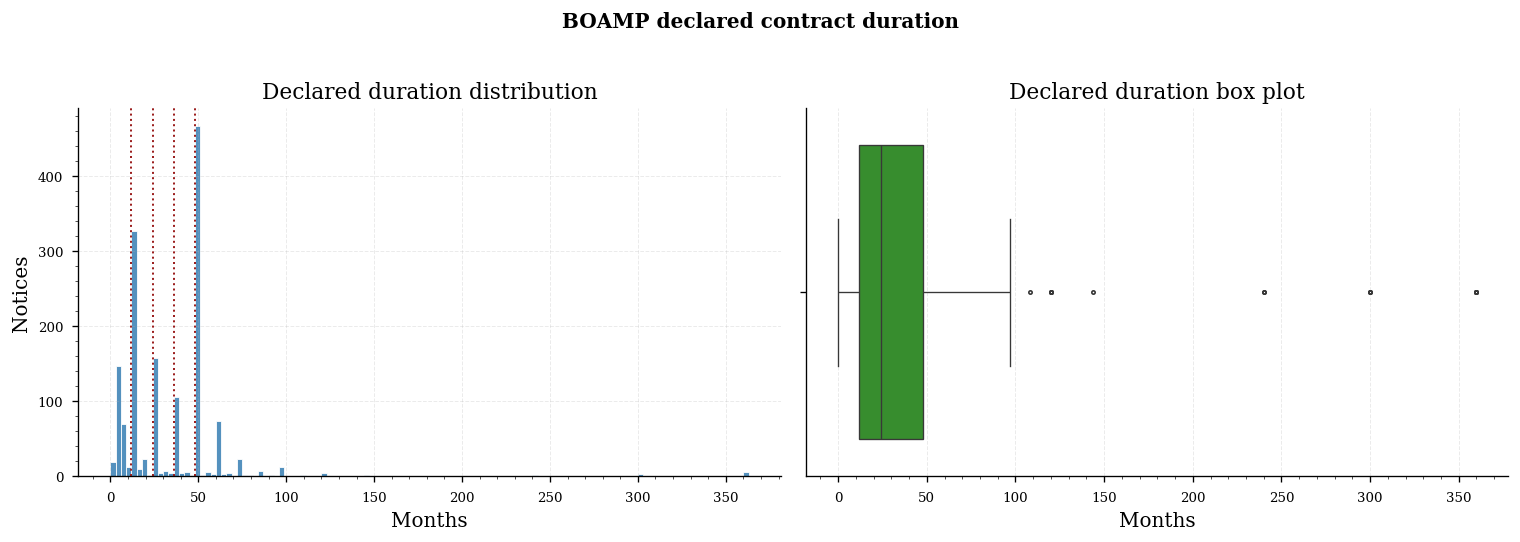

Saved → /home/senghakrou/stage-1/reports/figures/boamp_duration.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.4))

sns.histplot(dur, bins=range(0, int(dur.max()) + 6, 3), color=COLORS['blue'],
             edgecolor='white', linewidth=0.5, ax=axes[0])
for v in ROUND:
    axes[0].axvline(v, color=COLORS['red'], linestyle=':', linewidth=1.2)
axes[0].set(title='Declared duration distribution', xlabel='Months', ylabel='Notices')
finish_axes(axes[0])

sns.boxplot(x=dur, color=COLORS['green'], linewidth=0.8, fliersize=2, ax=axes[1])
axes[1].set(title='Declared duration box plot', xlabel='Months')
finish_axes(axes[1], grid_axis='x')

fig.suptitle('BOAMP declared contract duration', y=1.02, fontsize=12, fontweight='bold')
save_fig(fig, 'boamp_duration.png')
plt.show()

### 1.8  Buyers

Unique buyers: 525


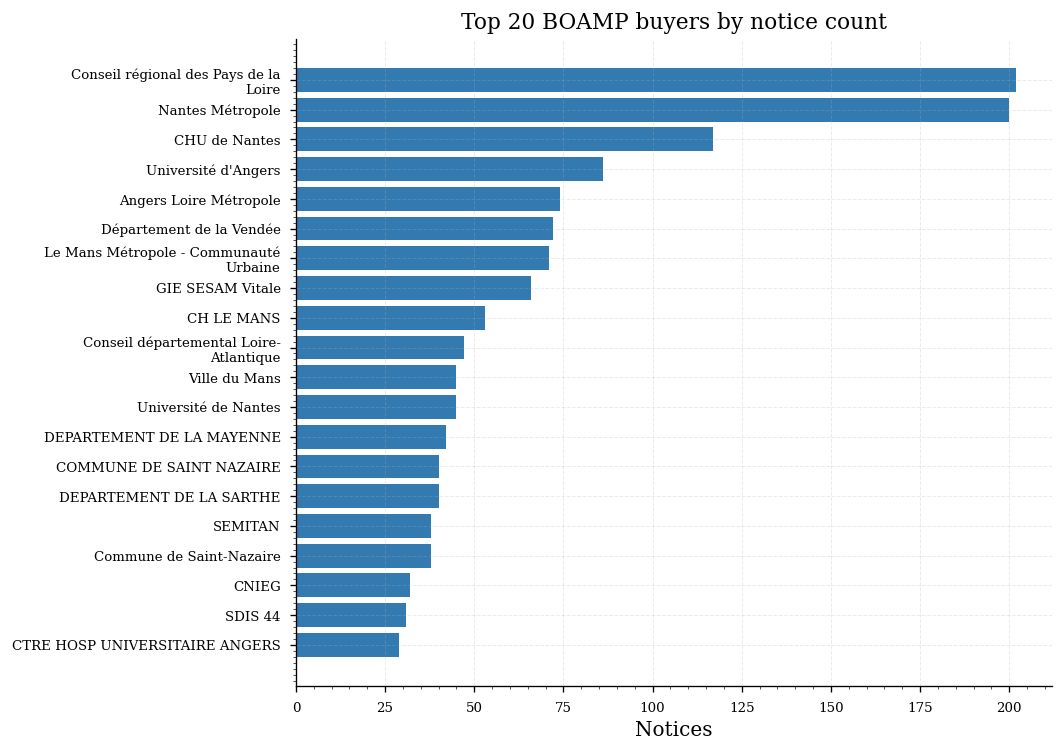

Saved → /home/senghakrou/stage-1/reports/figures/boamp_top_buyers.png


In [26]:
top_buyers = boamp['nomacheteur'].value_counts().head(20)
print(f'Unique buyers: {boamp["nomacheteur"].nunique()}')

fig, ax = plt.subplots(figsize=(9.0, 6.4))
sorted_buyers = top_buyers.sort_values()
ax.barh(wrap_labels(sorted_buyers.index, width=34), sorted_buyers.values,
        color=COLORS['blue'], alpha=0.9)
ax.set(title='Top 20 BOAMP buyers by notice count', xlabel='Notices', ylabel='')
finish_axes(ax, grid_axis='x')
save_fig(fig, 'boamp_top_buyers.png')
plt.show()

### 1.9  Publication → award gap (procurement procedure length)

Pairs with both dates: 538
count    538.000000
mean       4.826485
std        3.109589
min        0.591327
25%        2.964849
50%        3.975033
75%        5.436925
max       22.897503


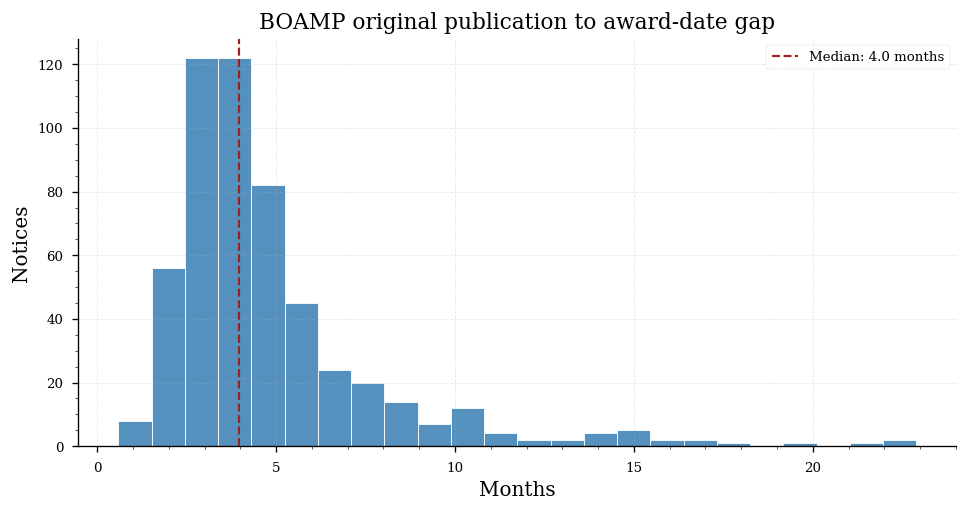

Saved → /home/senghakrou/stage-1/reports/figures/boamp_award_gap.png


In [27]:
pairs = boamp[boamp['date_attribution'].notna() &
              boamp['date_publication_anterieure'].notna()].copy()
pairs['gap_months'] = (
    (pairs['date_attribution'] - pairs['date_publication_anterieure'])
    .dt.days / 30.44
)
pairs = pairs[pairs['gap_months'].between(0, 24)]

print(f'Pairs with both dates: {len(pairs)}')
print(pairs['gap_months'].describe().to_string())

fig, ax = plt.subplots(figsize=(8.2, 4.4))
sns.histplot(pairs['gap_months'], bins=24, color=COLORS['blue'],
             edgecolor='white', linewidth=0.5, ax=ax)
median_gap = pairs['gap_months'].median()
ax.axvline(median_gap, color=COLORS['red'], linestyle='--', linewidth=1.3,
           label=f'Median: {median_gap:.1f} months')
ax.set(title='BOAMP original publication to award-date gap',
       xlabel='Months', ylabel='Notices')
ax.legend(loc='upper right')
finish_axes(ax)
save_fig(fig, 'boamp_award_gap.png')
plt.show()

---
## 2  DECP sample — EDA

In [28]:
decp = pd.read_csv(PROCESSED / 'decp_sample_flat.csv', low_memory=False)

decp['dateNotification']       = pd.to_datetime(decp['dateNotification'],       errors='coerce')
decp['datePublicationDonnees'] = pd.to_datetime(decp['datePublicationDonnees'], errors='coerce')
decp['year'] = decp['dateNotification'].dt.year

print(f'Shape: {decp.shape}')
decp.dtypes

Shape: (3039, 23)


uid                                  object
id                                   object
nature                               object
objet                                object
codeCPV                               int64
procedure                            object
dureeMois                           float64
dateNotification             datetime64[ns]
datePublicationDonnees       datetime64[ns]
montant                             float64
offresRecues                        float64
donneesActuelles                       bool
sourceDataset                        object
acheteur_id                           int64
acheteur_nom                         object
acheteur_departement_code             int64
acheteur_categorie                   object
titulaire_id                         object
titulaire_typeIdentifiant            object
titulaire_nom                        object
lieuExecution_code                   object
lieuExecution_typeCode               object
year                            

### 2.1  Completeness overview

In [29]:
missing_pct(decp)

,missing %,non-null
offresRecues,73.642646,800
acheteur_categorie,15.333991,2573
procedure,14.577164,2596
titulaire_nom,6.449490,2843
titulaire_typeIdentifiant,4.540967,2901
titulaire_id,4.508062,2902
montant,4.442251,2904
datePublicationDonnees,1.974334,2979
dureeMois,0.625206,3020
lieuExecution_code,0.131622,3035


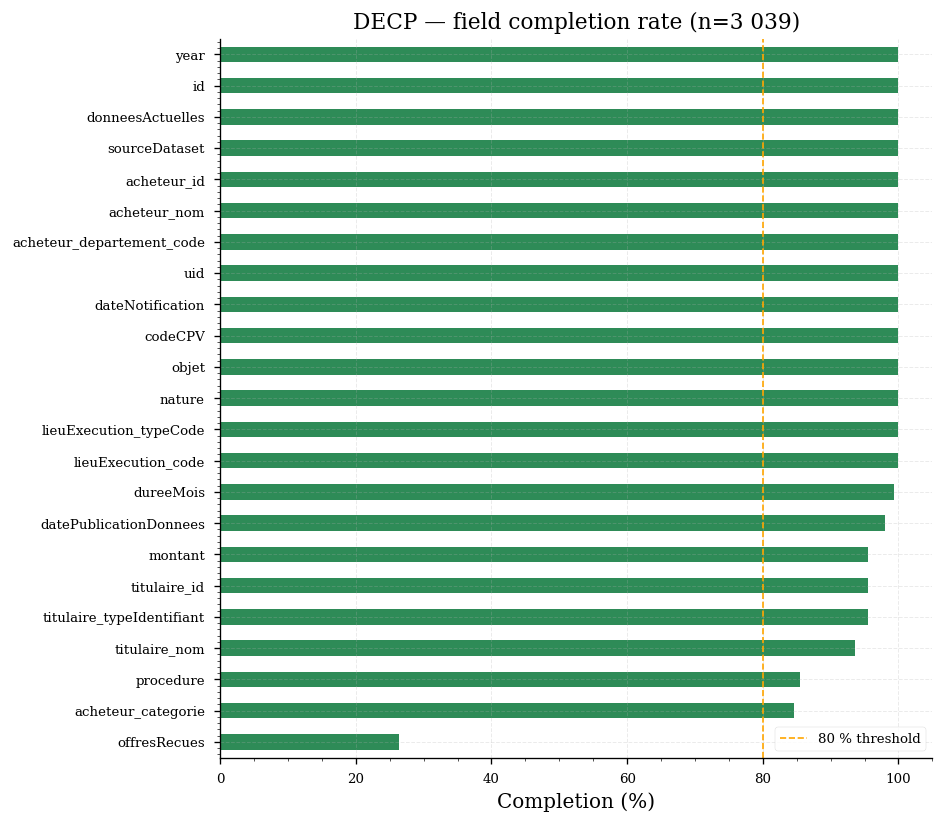

In [30]:
fill = (100 * decp.notna().mean()).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
fill.plot.barh(ax=ax, color='seagreen')
ax.axvline(80, color='orange', linestyle='--', lw=1, label='80 % threshold')
ax.set(xlabel='Completion (%)', title='DECP — field completion rate (n=3 039)')
ax.legend()
plt.tight_layout()
#plt.savefig(FIGURES / 'decp_completion.png', dpi=150)
plt.show()

### 2.2  Temporal distribution

In [31]:
print('Contracts per year (notification date):')
print(decp['year'].value_counts().sort_index().to_string())

Contracts per year (notification date):
year
2018     42
2019    361
2020    433
2021    506
2022    574
2023    561
2024    562


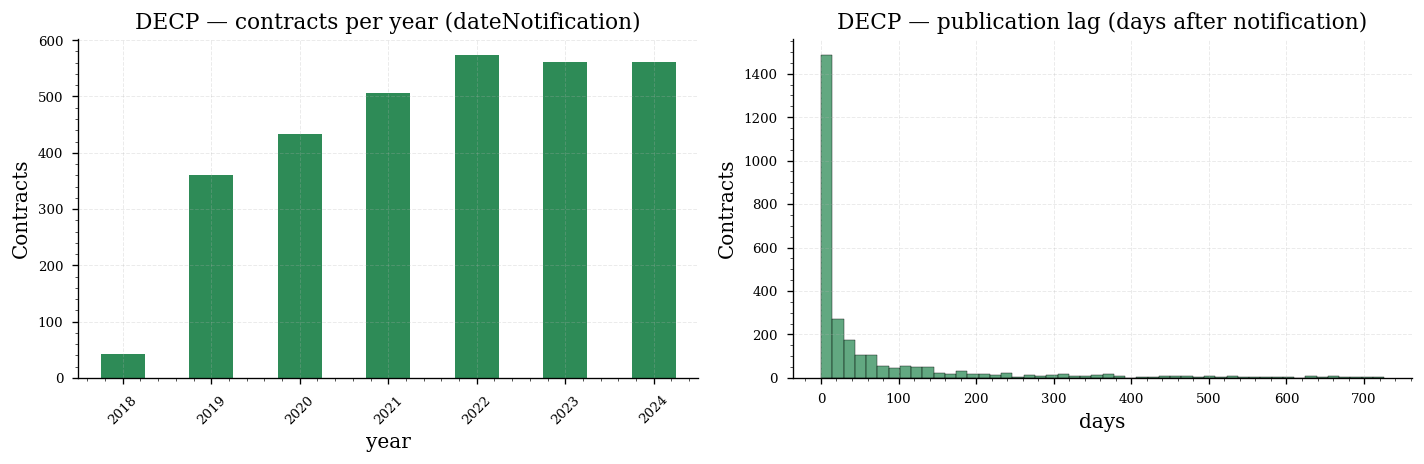

Median publication lag: 11 days


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

decp['year'].value_counts().sort_index().plot.bar(ax=axes[0], color='seagreen')
axes[0].set(title='DECP — contracts per year (dateNotification)', ylabel='Contracts')
axes[0].tick_params(axis='x', rotation=45)

lag_days = (decp['datePublicationDonnees'] - decp['dateNotification']).dt.days
lag_clean = lag_days[(lag_days >= 0) & (lag_days < 730)]
sns.histplot(lag_clean, bins=50, ax=axes[1], color='seagreen')
axes[1].set(title='DECP — publication lag (days after notification)',
            xlabel='days', ylabel='Contracts')

plt.tight_layout()
#plt.savefig(FIGURES / 'decp_temporal.png', dpi=150)
plt.show()

print(f'Median publication lag: {lag_clean.median():.0f} days')

### 2.3  Department and contract nature

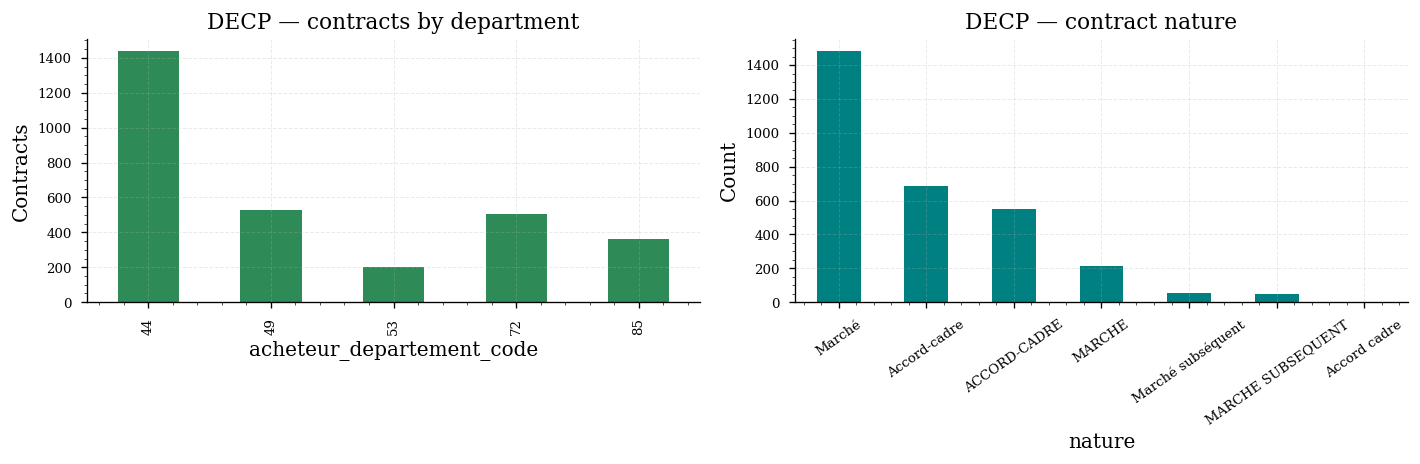

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

decp['acheteur_departement_code'].value_counts().sort_index().plot.bar(
    ax=axes[0], color='seagreen')
axes[0].set(title='DECP — contracts by department', ylabel='Contracts')

decp['nature'].value_counts().plot.bar(ax=axes[1], color='teal')
axes[1].set(title='DECP — contract nature', ylabel='Count')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
#plt.savefig(FIGURES / 'decp_dept_nature.png', dpi=150)
plt.show()

### 2.4  Procedure and buyer category

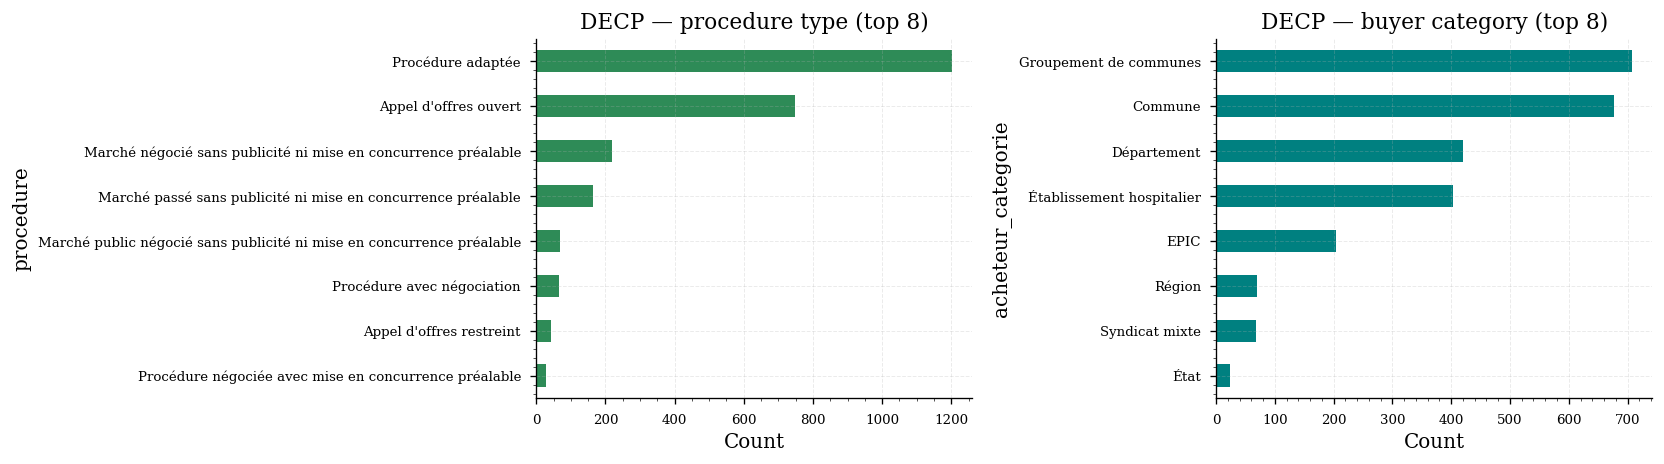

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

decp['procedure'].value_counts().head(8).plot.barh(ax=axes[0], color='seagreen')
axes[0].set(title='DECP — procedure type (top 8)', xlabel='Count')
axes[0].invert_yaxis()

decp['acheteur_categorie'].value_counts().head(8).plot.barh(ax=axes[1], color='teal')
axes[1].set(title='DECP — buyer category (top 8)', xlabel='Count')
axes[1].invert_yaxis()

plt.tight_layout()
#plt.savefig(FIGURES / 'decp_procedure_cat.png', dpi=150)
plt.show()

### 2.5  CPV codes

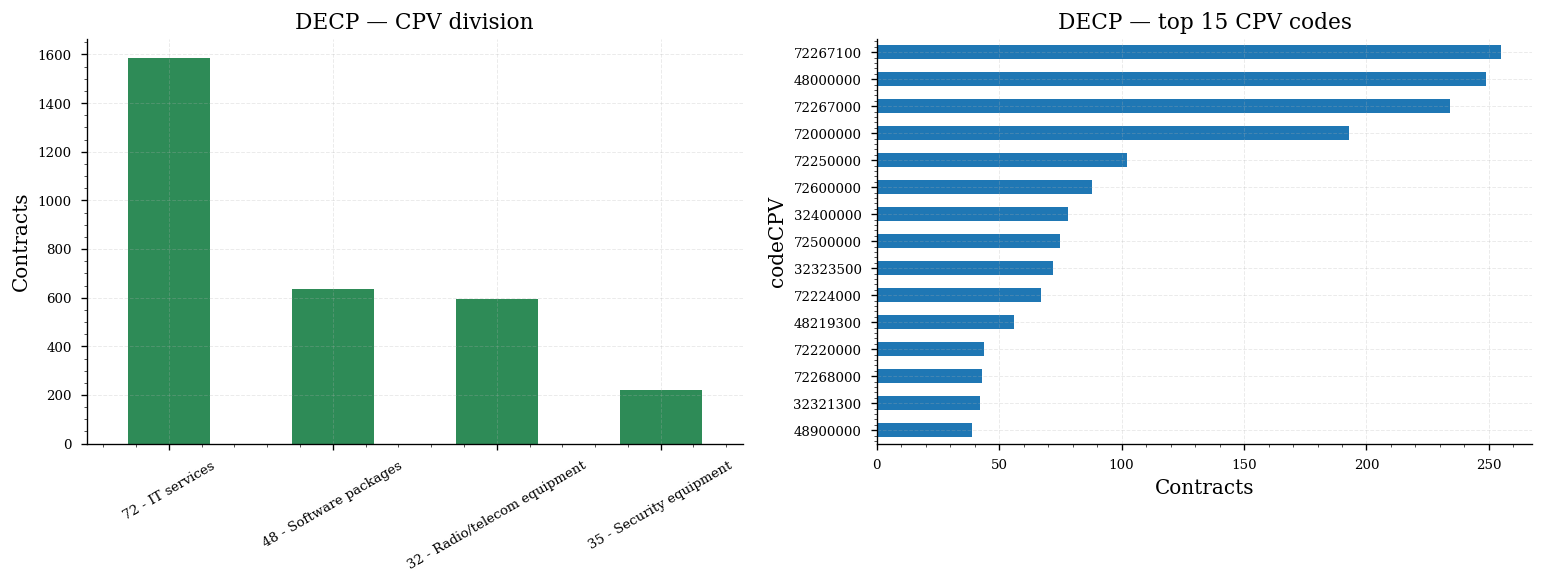

In [35]:
decp['cpv_div'] = decp['codeCPV'].astype(str).str[:2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

div_counts = decp['cpv_div'].value_counts()
div_counts.index = [cpv_div_labels.get(x, x) for x in div_counts.index]
div_counts.plot.bar(ax=axes[0], color='seagreen')
axes[0].set(title='DECP — CPV division', ylabel='Contracts')
axes[0].tick_params(axis='x', rotation=30)

top_cpv = decp['codeCPV'].value_counts().head(15)
top_cpv.plot.barh(ax=axes[1])
axes[1].set(title='DECP — top 15 CPV codes', xlabel='Contracts')
axes[1].invert_yaxis()

plt.tight_layout()
#plt.savefig(FIGURES / 'decp_cpv.png', dpi=150)
plt.show()

### 2.6  Amount distribution

In [36]:
amt_d = decp['montant'].dropna()
print(f'Filled: {len(amt_d)}/{len(decp)} ({len(amt_d)/len(decp):.1%})')
print(amt_d.describe().to_string())

flags = {
    'amount == 0'    : int((amt_d == 0).sum()),
    'amount < 1 000' : int((amt_d < 1_000).sum()),
    'amount >= 10 M' : int((amt_d >= 10_000_000).sum()),
}
for k, v in flags.items():
    print(f'  {k}: {v} ({v/len(amt_d):.1%})')

Filled: 2904/3039 (95.6%)
count    2.904000e+03
mean     1.702067e+06
std      3.272502e+07
min      0.000000e+00
25%      4.765025e+04
50%      1.000000e+05
75%      2.400000e+05
max      1.000000e+09
  amount == 0: 31 (1.1%)
  amount < 1 000: 51 (1.8%)
  amount >= 10 M: 23 (0.8%)


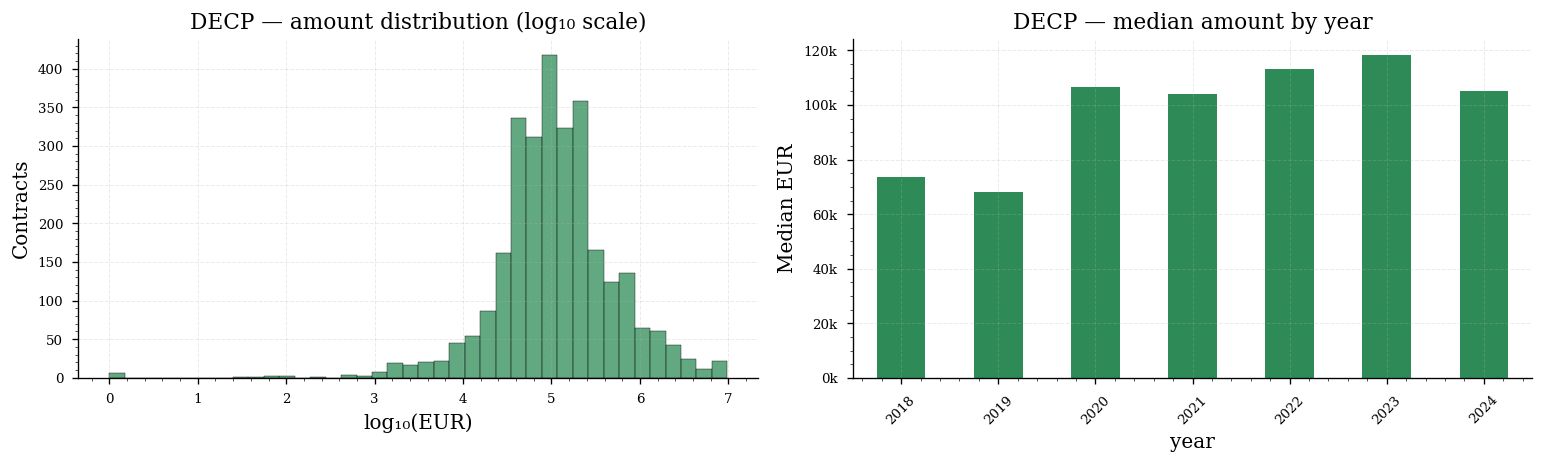

In [37]:
amt_d_clean = amt_d[(amt_d > 0) & (amt_d < 10_000_000)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(np.log10(amt_d_clean), bins=40, ax=axes[0], color='seagreen')
axes[0].set(title='DECP — amount distribution (log₁₀ scale)',
            xlabel='log₁₀(EUR)', ylabel='Contracts')

amt_by_year = (
    decp[decp['montant'].notna()]
    .groupby('year')['montant']
    .median()
)
amt_by_year.plot.bar(ax=axes[1], color='seagreen')
axes[1].set(title='DECP — median amount by year', ylabel='Median EUR')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig(FIGURES / 'decp_amount.png', dpi=150)
plt.show()

### 2.7  Contract duration (dureeMois)

In [38]:
dur_d = decp['dureeMois'].dropna()
print(f'Filled: {len(dur_d)}/{len(decp)} ({len(dur_d)/len(decp):.1%})')
print(dur_d.describe().to_string())
print()
print(f'  exactly 12/24/36/48: {dur_d.isin(ROUND).sum()} ({dur_d.isin(ROUND).mean():.1%})')
print(f'  whole-year multiple : {(dur_d % 12 == 0).sum()} ({(dur_d % 12 == 0).mean():.1%})')
print(f'  > 120 months        : {(dur_d > 120).sum()} ({(dur_d > 120).mean():.1%})')

Filled: 3020/3039 (99.4%)
count    3020.000000
mean       38.543377
std        23.002810
min         0.000000
25%        24.000000
50%        48.000000
75%        48.000000
max       475.000000

  exactly 12/24/36/48: 2002 (66.3%)
  whole-year multiple : 2234 (74.0%)
  > 120 months        : 4 (0.1%)


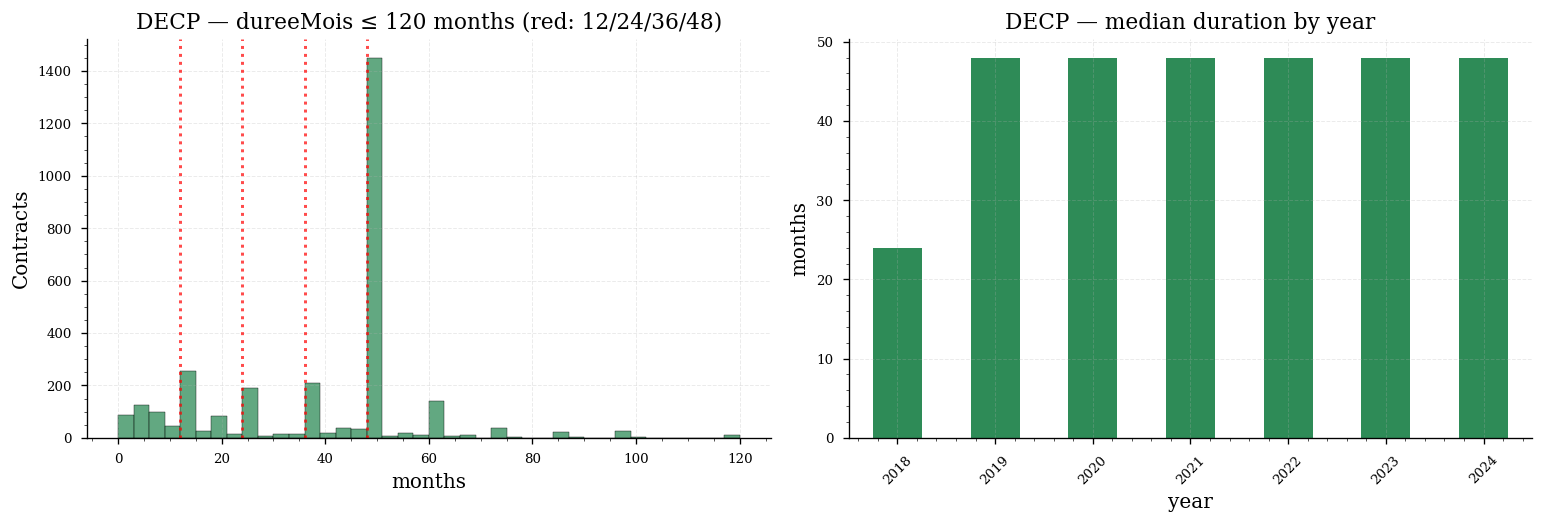

In [39]:
dur_d_trim = dur_d[dur_d <= 120]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(dur_d_trim, bins=range(0, 121, 3), ax=axes[0], color='seagreen')
for v in ROUND:
    axes[0].axvline(v, color='red', linestyle=':', alpha=0.7)
axes[0].set(title='DECP — dureeMois ≤ 120 months (red: 12/24/36/48)',
            xlabel='months', ylabel='Contracts')

decp.groupby('year')['dureeMois'].median().plot.bar(ax=axes[1], color='seagreen')
axes[1].set(title='DECP — median duration by year', ylabel='months')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig(FIGURES / 'decp_duration.png', dpi=150)
plt.show()

### 2.8  Competition signal — offresRecues

Filled: 801/3039 (26.4%)
count    801.000000
mean       3.765293
std        4.861568
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       34.000000


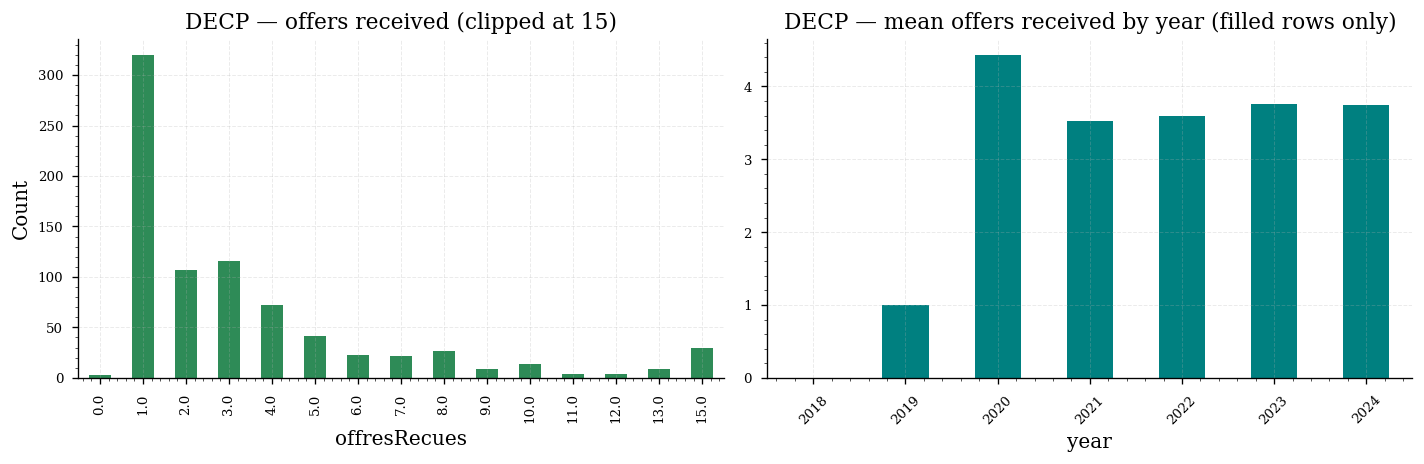

In [40]:
off = decp['offresRecues'].dropna()
print(f'Filled: {len(off)}/{len(decp)} ({len(off)/len(decp):.1%})')
print(off.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

off.clip(upper=15).value_counts().sort_index().plot.bar(ax=axes[0], color='seagreen')
axes[0].set(title='DECP — offers received (clipped at 15)', ylabel='Count')

decp.groupby('year')['offresRecues'].mean().plot.bar(ax=axes[1], color='teal')
axes[1].set(title='DECP — mean offers received by year (filled rows only)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig(FIGURES / 'decp_offers.png', dpi=150)
plt.show()

### 2.9  Top buyers

Unique buyers (SIRET): 294
Unique buyers (name):  278


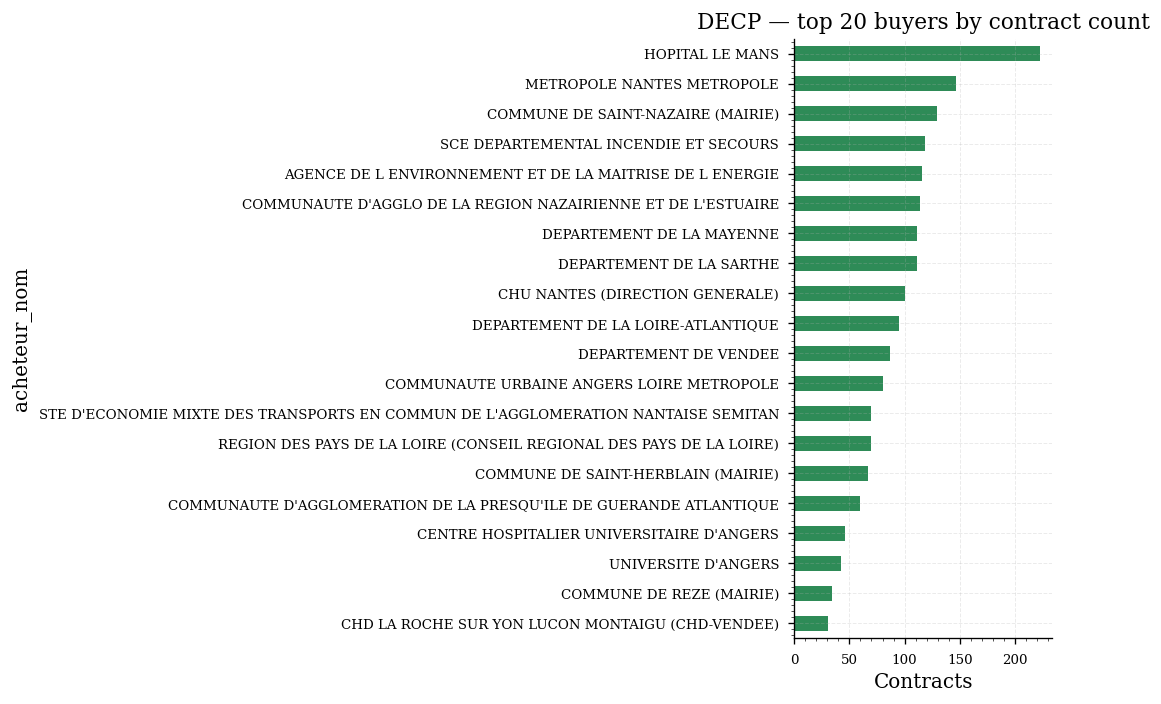

In [41]:
print(f'Unique buyers (SIRET): {decp["acheteur_id"].nunique()}')
print(f'Unique buyers (name):  {decp["acheteur_nom"].nunique()}')

top = decp.groupby('acheteur_nom').size().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top.sort_values().plot.barh(ax=ax, color='seagreen')
ax.set(title='DECP — top 20 buyers by contract count', xlabel='Contracts')
plt.tight_layout()
#plt.savefig(FIGURES / 'decp_top_buyers.png', dpi=150)
plt.show()

---
## 3  Cross-source comparison

### 3.1  Volume by year

      BOAMP  DECP
year             
2015    177     0
2016    278     0
2017    315     0
2018    328    42
2019    313   361
2020    343   433
2021    342   506
2022    398   574
2023    389   561
2024    298   562


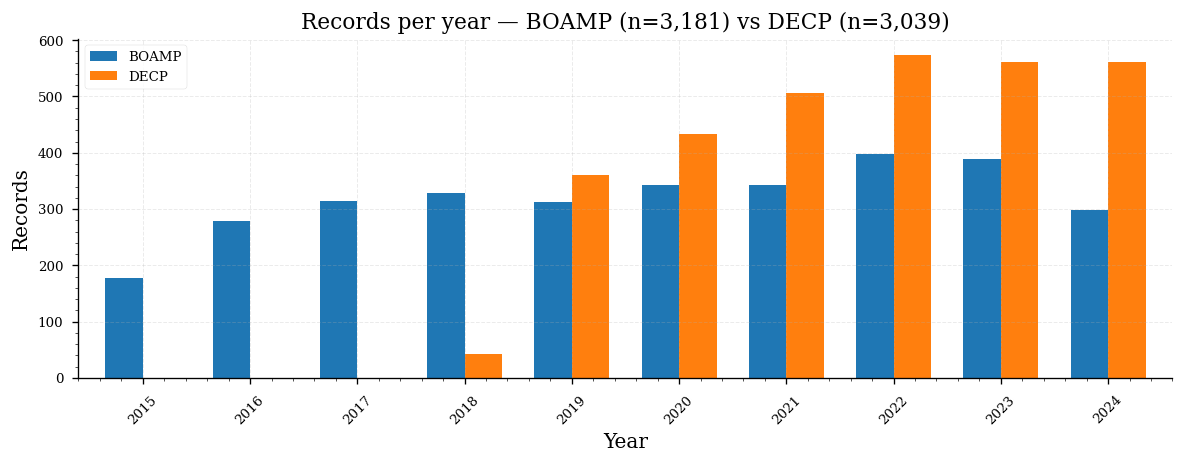

In [42]:
b_yr = boamp['year'].value_counts().sort_index().rename('BOAMP')
d_yr = decp['year'].value_counts().sort_index().rename('DECP')
vol = pd.concat([b_yr, d_yr], axis=1).fillna(0).astype(int)
print(vol.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
vol.plot.bar(ax=ax, width=0.7)
ax.set(title='Records per year — BOAMP (n=3,181) vs DECP (n=3,039)',
       xlabel='Year', ylabel='Records')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
#plt.savefig(FIGURES / 'cross_volume.png', dpi=150)
plt.show()

### 3.2  CPV division distribution

                                 BOAMP %  DECP %
72 - IT services                    42.0    52.2
48 - Software packages              19.4    20.9
32 - Radio/telecom equipment        16.1    19.6
35 - Security equipment              6.9     7.3
45                                   4.0     0.0
30 - Office/computing machinery      1.9     0.0
39                                   1.3     0.0
79                                   1.2     0.0
50                                   1.2     0.0
64                                   1.0     0.0
71                                   0.9     0.0
18                                   0.9     0.0
44                                   0.6     0.0
38                                   0.3     0.0
90                                   0.3     0.0
31                                   0.3     0.0
37                                   0.3     0.0
34                                   0.3     0.0
42                                   0.3     0.0
92                  

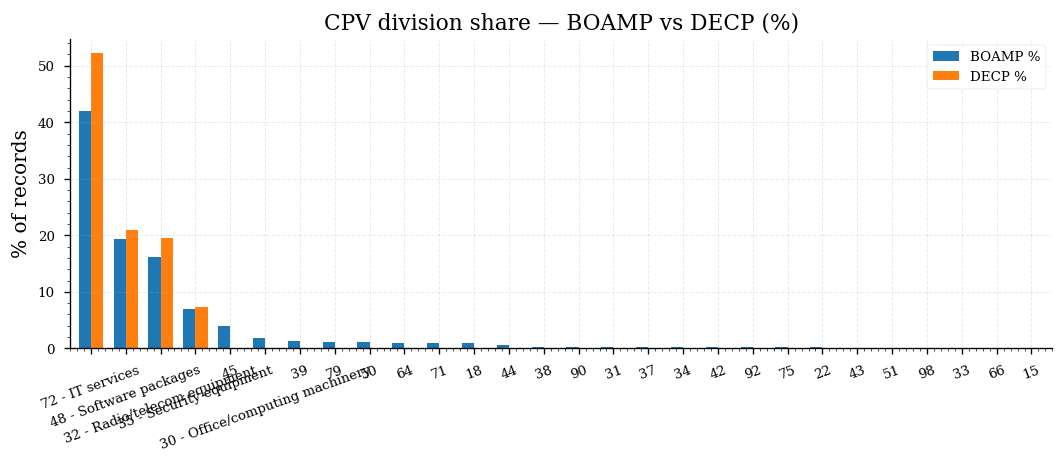

In [43]:
b_cpv = (boamp['cpv_div'].value_counts(normalize=True) * 100).rename('BOAMP %')
d_cpv = (decp['cpv_div'].value_counts(normalize=True) * 100).rename('DECP %')
cpv_comp = pd.concat([b_cpv, d_cpv], axis=1).fillna(0).round(1)
cpv_comp.index = [cpv_div_labels.get(x, x) for x in cpv_comp.index]
print(cpv_comp.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
cpv_comp.plot.bar(ax=ax, width=0.7)
ax.set(title='CPV division share — BOAMP vs DECP (%)', ylabel='% of records')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
#plt.savefig(FIGURES / 'cross_cpv.png', dpi=150)
plt.show()

### 3.3  Amount distributions

BOAMP amount_eur vs DECP montant — key percentiles:
        BOAMP (EUR)   DECP (EUR)
count  1.369000e+03       2904.0
mean   1.461785e+10    1702067.0
std    3.820798e+11   32725018.0
min    0.000000e+00          0.0
25%    2.000000e+05      47650.0
50%    4.000000e+05     100000.0
75%    9.999990e+05     240000.0
max    1.000000e+13  999999999.0


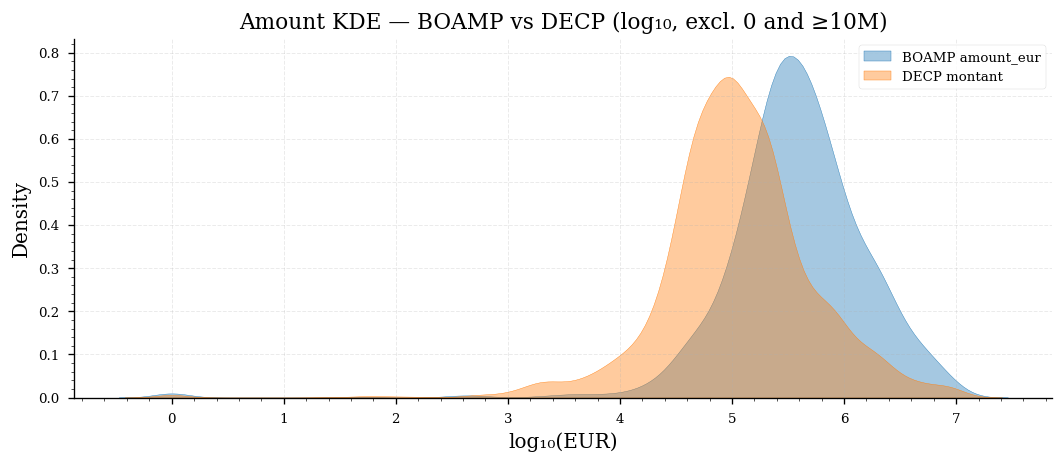

In [44]:
b_amt = boamp['amount_eur'].dropna()
d_amt = decp['montant'].dropna()

print('BOAMP amount_eur vs DECP montant — key percentiles:')
comp = pd.DataFrame({
    'BOAMP (EUR)': b_amt.describe(),
    'DECP (EUR)' : d_amt.describe()
}).round(0)
print(comp.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
b_clean = b_amt[(b_amt > 0) & (b_amt < 10_000_000)]
d_clean = d_amt[(d_amt > 0) & (d_amt < 10_000_000)]
sns.kdeplot(np.log10(b_clean), ax=ax, label='BOAMP amount_eur', fill=True, alpha=0.4)
sns.kdeplot(np.log10(d_clean), ax=ax, label='DECP montant',     fill=True, alpha=0.4)
ax.set(title='Amount KDE — BOAMP vs DECP (log₁₀, excl. 0 and ≥10M)',
       xlabel='log₁₀(EUR)')
ax.legend()
plt.tight_layout()
#plt.savefig(FIGURES / 'cross_amount.png', dpi=150)
plt.show()

### 3.4  Duration distributions

Duration percentiles (months):
       BOAMP duration_months  DECP dureeMois
count                 1518.0          3020.0
mean                    32.8            38.5
std                     31.7            23.0
min                      0.0             0.0
25%                     12.0            24.0
50%                     24.0            48.0
75%                     48.0            48.0
max                    360.0           475.0


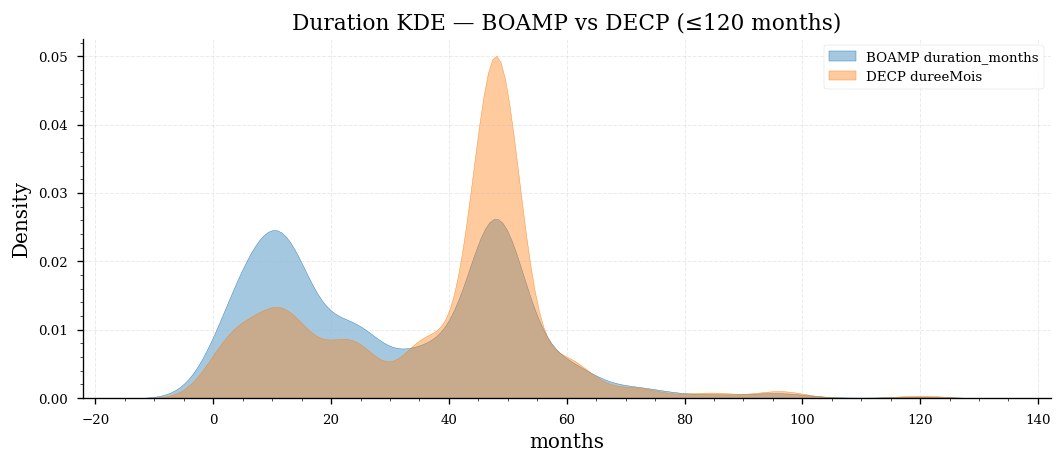

In [45]:
b_dur = boamp['duration_months'].dropna()
d_dur = decp['dureeMois'].dropna()

print('Duration percentiles (months):')
print(pd.DataFrame({'BOAMP duration_months': b_dur.describe(),
                    'DECP dureeMois'       : d_dur.describe()}).round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(b_dur[b_dur <= 120], ax=ax, label='BOAMP duration_months', fill=True, alpha=0.4)
sns.kdeplot(d_dur[d_dur <= 120], ax=ax, label='DECP dureeMois',        fill=True, alpha=0.4)
ax.set(title='Duration KDE — BOAMP vs DECP (≤120 months)', xlabel='months')
ax.legend()
plt.tight_layout()
#plt.savefig(FIGURES / 'cross_duration.png', dpi=150)
plt.show()

### 3.5  Key field completeness side-by-side

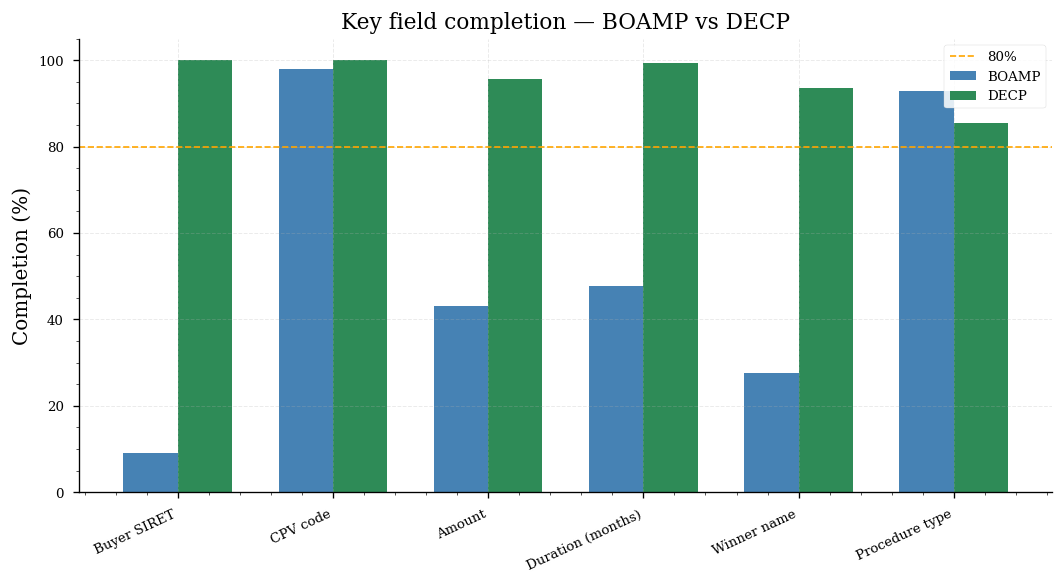

                   BOAMP   DECP
Field                          
Buyer SIRET          9.1  100.0
CPV code            98.1  100.0
Amount              43.0   95.6
Duration (months)   47.7   99.4
Winner name         27.6   93.6
Procedure type      92.9   85.4


In [46]:
shared = [
    ('Buyer SIRET',      boamp['buyer_siret'].notna().mean(),    decp['acheteur_id'].notna().mean()),
    ('CPV code',         boamp['cpv_principal'].notna().mean(),  decp['codeCPV'].notna().mean()),
    ('Amount',           boamp['amount_eur'].notna().mean(),     decp['montant'].notna().mean()),
    ('Duration (months)',boamp['duration_months'].notna().mean(),decp['dureeMois'].notna().mean()),
    ('Winner name',      boamp['titulaire'].notna().mean(),      decp['titulaire_nom'].notna().mean()),
    ('Procedure type',   boamp['type_procedure'].notna().mean(), decp['procedure'].notna().mean()),
]

comp_df = pd.DataFrame(shared, columns=['Field', 'BOAMP', 'DECP'])
comp_df[['BOAMP', 'DECP']] = comp_df[['BOAMP', 'DECP']] * 100

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comp_df))
w = 0.35
ax.bar(x - w/2, comp_df['BOAMP'], w, label='BOAMP', color='steelblue')
ax.bar(x + w/2, comp_df['DECP'],  w, label='DECP',  color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(comp_df['Field'], rotation=25, ha='right')
ax.set(ylabel='Completion (%)', title='Key field completion — BOAMP vs DECP', ylim=(0, 105))
ax.axhline(80, linestyle='--', color='orange', lw=1, label='80%')
ax.legend()
plt.tight_layout()
#plt.savefig(FIGURES / 'cross_completeness.png', dpi=150)
plt.show()

print(comp_df.set_index('Field').round(1).to_string())

---
## 4  Summary and key findings

| Dimension | BOAMP (n=3,181) | DECP (n=3,039) |
|---|---|---|
| Period | 2015–2024 (50/year) | 2018–2024 (sparse before 2019) |
| Buyer SIRET | 8% (eForms 2024 only) | 100% (mandatory) |
| Amount | 44.6% | 95.6% |
| Duration | 34.4% | 99.4% |
| Notification date | absent | 100% |
| Award date | 41.8% (award notices) | absent |
| Notice type | 100% (`nature`) | absent |
| Linked notices | 46.2% (`annonce_lie`) | absent |

**Duration coarseness.** Both sources show heavy rounding: ~70% of BOAMP values and ~66% of DECP values fall exactly on 12/24/36/48 months. Declared duration should be used as a covariate / renewal search window prior, not as the survival target.

**Amount cleaning rules** (apply to both):
- Remove zeros and values below €1 000 (likely encoding errors)  
- Flag values ≥ €10 M as potential lot aggregates or ceiling entries

**Source strategy (confirmed):**
- **BOAMP** = primary corpus (full 2015–2024 coverage, event structure for survival analysis, `annonce_lie` for renewal linking)
- **DECP** = enrichment from 2019 onwards (SIRET, amount, `dureeMois`, `dateNotification`)